# Ebola流行の国別・報告時系列分析

run_id: `v020-exp-25`。Kaggle公開データを第一候補とし、API取得不能の場合のみ指定公開CSVを使う。記述的分析であり、感染発生日・個人の転帰・介入効果は推定しない。認証情報はNotebook・出力・ログに保存しない。

In [1]:
from pathlib import Path
import sys, os, json, hashlib, io, re, contextlib, warnings
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager
import numpy as np
import pandas as pd
import nbformat
from IPython.display import display, Markdown
import matplotlib
matplotlib.rcParams['figure.autolayout'] = True
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions
from ai_data_scientist import data_quality, sensitivity, visualization, insight_engine, notebook_audit
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-25-ebola')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
RUN_ID = 'v020-exp-25'
lifecycle.register_run(RUN_ID, handle.notebook_path)
language = language_router.detect_language('国別・時系列の報告症例と死亡の推移を調べてください')
lifecycle_log = data_dir / 'lifecycle.jsonl'
def log_state(event):
    record = {'time_utc': datetime.now(timezone.utc).isoformat(), 'event': event, **asdict(lifecycle.get_run_status(RUN_ID))}
    with lifecycle_log.open('a', encoding='utf-8') as f:
        f.write(json.dumps(record, ensure_ascii=False) + '\n')
@contextmanager
def phase(name, writing=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検出したため新しい処理を中止')
    start = lifecycle.mark_write_start if writing else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if writing else lifecycle.mark_execution_end
    start(RUN_ID)
    log_state(name + ':start')
    try:
        yield
    except BaseException:
        lifecycle.mark_failed(RUN_ID)
        log_state(name + ':failed')
        raise
    finally:
        end(RUN_ID)
        log_state(name + ':end')
def save_json(name, value):
    with phase('artifact:' + name, writing=True):
        (data_dir / name).write_text(json.dumps(value, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
log_state('registered')
print('run_id:', RUN_ID, 'language:', language)
print('Notebook:', handle.notebook_path)
print('状態:', asdict(lifecycle.get_run_status(RUN_ID)))


run_id: v020-exp-25 language: ja
Notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-25-ebola/notebooks/kaggle-v020-kaggle-exp-25-ebola.ipynb
状態: {'run_id': 'v020-exp-25', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-25-ebola/notebooks/kaggle-v020-kaggle-exp-25-ebola.ipynb', 'reason': None}


## 取得計画と再実行方針

初回はインストール済みKaggle SDKで認証・検索・ファイル一覧・取得を実施する。再実行は取得日時とSHA-256を固定したローカルスナップショットを検証して使い、ネットワーク変化を分析再現性から分離する。Kaggleの失敗記録は処理段階・例外型・HTTP状態に限定し、秘密情報を含み得る例外本文は出力しない。

In [2]:
# KaggleのSDK出力は捕捉して破棄し、認証情報・例外本文・HTTPヘッダーを表示しない。
with phase('kaggle-search'):
    provenance_path = data_dir / 'provenance.json'
    cached = json.loads(provenance_path.read_text()) if provenance_path.exists() else None
    acquisition_reused = False
    kaggle_log = []
    candidates = []
    api = None
    if cached is not None:
        cached_file = data_dir / cached['local_filename']
        if not cached_file.exists() or hashlib.sha256(cached_file.read_bytes()).hexdigest() != cached['sha256']:
            raise RuntimeError('保存データのSHA-256不一致: 自動的な再取得で上書きしない')
        acquisition_reused = True
        provenance = cached
        kaggle_log = cached['kaggle_attempts']
        print('再実行: 固定した取得済みファイルをSHA-256検証して再使用')
    else:
        stage = 'SDK import'
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                from kaggle.api.kaggle_api_extended import KaggleApi
                stage = 'KaggleApi().authenticate()'
                api = KaggleApi()
                api.authenticate()
            kaggle_log.append({'stage': stage, 'status': 'success'})
            for query in ['ebola', 'ebola cases deaths']:
                stage = 'dataset_list(search=' + query + ')'
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    found = api.dataset_list(search=query)
                refs = [str(item.ref) for item in found]
                candidates.extend(refs)
                kaggle_log.append({'stage': stage, 'status': 'success', 'public_refs': refs})
        except (Exception, SystemExit) as exc:
            # 本文は認証情報を含む可能性があるため保存せず、型・処理段階・HTTP状態のみ残す。
            http_status = getattr(exc, 'status', None)
            kaggle_log.append({'stage': stage, 'status': 'failed', 'exception_type': type(exc).__name__, 'http_status': http_status if isinstance(http_status, int) else None, 'reason': 'Kaggle SDK/API検索が完了しなかった。例外本文は秘密情報保護のため非保存。'})
        candidates = list(dict.fromkeys(candidates))
    print(json.dumps({'reused': acquisition_reused, 'kaggle_attempts': kaggle_log, 'candidate_refs': candidates}, ensure_ascii=False, indent=2))


再実行: 固定した取得済みファイルをSHA-256検証して再使用
{
  "reused": true,
  "kaggle_attempts": [
    {
      "stage": "KaggleApi().authenticate()",
      "status": "success"
    },
    {
      "stage": "dataset_list(search=ebola)",
      "status": "success",
      "public_refs": [
        "imdevskp/ebola-outbreak-20142016-complete-dataset",
        "zkskhurram/ebola-virus-insight-global-epidemiology",
        "kingburrito666/ebola-cases",
        "imdevskp/corona-virus-report",
        "jocelyndumlao/ebola-outbreaks-before-2014",
        "mathurinache/microbescope-coronavirus-zika-ebola",
        "imdevskp/covid19-corona-virus-india-dataset",
        "imdevskp/sars-outbreak-2003-complete-dataset",
        "akiator9/ebolav-vs-sarscov-vs-mers",
        "imdevskp/hiv-aids-dataset",
        "nishantbhadauria/coronavirus-genome-vs-zikamersebola",
        "imdevskp/mers-outbreak-dataset-20122019",
        "parulkhare26/ebola-data",
        "imdevskp/h1n1-swine-flu-2009-pandemic-dataset",
        "ssarkar445/west

## Kaggleの対応ファイル選定と取得

検索で確認した公開slugに対して`dataset_list_files`を呼び、清掃済みCSVを優先して`dataset_download_file`を実施する。列構造を確認してから採用し、元ファイルをハッシュ固定する。

In [3]:
with phase('kaggle-files-and-download'):
    file_catalog = []
    metadata_refs = []
    if not acquisition_reused:
        preferred = ['imdevskp/ebola-outbreak-20142016-complete-dataset', 'kingburrito666/ebola-cases', 'kayupe/number-of-ebola-cases-and-deaths', 'anairamcosta/country-timeseries']
        choices = [ref for ref in preferred if ref in candidates]
        for ref in choices:
            stage = 'dataset_list_files(' + ref + ')'
            try:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    listing = api.dataset_list_files(ref)
                files = [{'name': f.name, 'size': getattr(f, 'total_bytes', None)} for f in listing.files]
                file_catalog.append({'ref': ref, 'files': files})
                kaggle_log.append({'stage': stage, 'status': 'success', 'files': files})
                # 清掃済みcountry/date/cases/deaths型CSVを優先し、生データを混合・加算しない。
                csv_files = [f['name'] for f in files if f['name'].lower().endswith('.csv')]
                csv_files.sort(key=lambda n: (0 if 'clean' in n.lower() else 1, n))
                for filename in csv_files:
                    stage = 'dataset_download_file(' + ref + ', ' + filename + ')'
                    destination = data_dir / 'kaggle-download'
                    destination.mkdir(exist_ok=True)
                    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                        downloaded = api.dataset_download_file(ref, filename, path=str(destination), force=True, quiet=True)
                    import zipfile
                    raw_path = destination / Path(filename).name
                    zip_path = destination / (Path(filename).name + '.zip')
                    if raw_path.exists():
                        raw_bytes = raw_path.read_bytes()
                    elif zip_path.exists():
                        with zipfile.ZipFile(zip_path) as z:
                            members = [n for n in z.namelist() if Path(n).name == Path(filename).name]
                            if len(members) != 1:
                                raise ValueError('ZIP内で取得CSVを一意に特定できない')
                            raw_bytes = z.read(members[0])
                    else:
                        raise FileNotFoundError('SDKが返したダウンロードファイルを確認できない')
                    preview = pd.read_csv(io.BytesIO(raw_bytes))
                    lower_cols = {str(c).lower().strip() for c in preview.columns}
                    country_time = any('country' in c for c in lower_cols) and any('date' in c for c in lower_cols)
                    counts = any('case' in c for c in lower_cols) and any('death' in c for c in lower_cols)
                    if not (country_time and counts):
                        kaggle_log.append({'stage': stage, 'status':'not_selected', 'columns':list(preview.columns), 'reason':'国・日付・症例・死亡列の対応を自動確認できない'})
                        continue
                    local_filename = 'ebola-source.csv'
                    with phase('write-acquired-csv', writing=True):
                        (data_dir / local_filename).write_bytes(raw_bytes)
                    provenance = {'source_type':'Kaggle', 'owner_dataset_slug':ref, 'retrieved_filename':filename, 'local_filename':local_filename, 'retrieved_at_utc':datetime.now(timezone.utc).isoformat(), 'sha256':hashlib.sha256(raw_bytes).hexdigest(), 'url':'https://www.kaggle.com/datasets/' + ref, 'kaggle_attempts':kaggle_log + [{'stage':stage, 'status':'success'}], 'selection_reason':'公開検索結果から国・日付・症例・死亡列を備えたCSVを取得。清掃済み版の変換履歴は別途検証。', 'fallback_used':False}
                    kaggle_log = provenance['kaggle_attempts']
                    break
                else:
                    continue
                break
            except (Exception, SystemExit) as exc:
                status = getattr(exc, 'status', None)
                kaggle_log.append({'stage':stage, 'status':'failed', 'exception_type':type(exc).__name__, 'http_status':status if isinstance(status,int) else None, 'reason':'一覧取得またはCSV取得・構造確認に失敗。例外本文は非保存。'})
        else:
            # この分岐はKaggleの対応CSVを取得できなかった場合にのみ到達する。
            import urllib.request
            fallback_url = 'https://raw.githubusercontent.com/plotly/datasets/master/2014_ebola.csv'
            request = urllib.request.Request(fallback_url, headers={'User-Agent':'Jupytermind descriptive research'})
            with urllib.request.urlopen(request, timeout=30) as response:
                raw_bytes = response.read(5000001)
            if len(raw_bytes) > 5000000:
                raise ValueError('フォールバックCSVのサイズ上限超過')
            (data_dir / 'ebola-source.csv').write_bytes(raw_bytes)
            provenance = {'source_type':'Plotly public fallback CSV', 'owner_dataset_slug':None, 'retrieved_filename':'2014_ebola.csv', 'local_filename':'ebola-source.csv', 'retrieved_at_utc':datetime.now(timezone.utc).isoformat(), 'sha256':hashlib.sha256(raw_bytes).hexdigest(), 'url':fallback_url, 'kaggle_attempts':kaggle_log, 'fallback_used':True, 'fallback_reason':'Kaggle APIで対応する国別・時系列CSVの取得を完了できなかった', 'identity_caveat':'公開CSVとKaggle掲載版の完全な同一性は保証されない'}
        save_json('provenance.json', provenance)
        save_json('kaggle-file-catalog.json', file_catalog)
    raw_file = data_dir / provenance['local_filename']
    raw_bytes = raw_file.read_bytes()
    assert hashlib.sha256(raw_bytes).hexdigest() == provenance['sha256']
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(raw_file)), row_limit=100000)
    if loaded.truncated:
        raise ValueError('CSVが行数上限を超えた:切り捨てたデータを分析しない')
    raw = loaded.dataframe
    print('取得証跡:', json.dumps(provenance, ensure_ascii=False, indent=2))
    print('CSV一覧:', json.dumps(file_catalog, ensure_ascii=False))
    print('構造:', raw.shape, '列:', list(raw.columns))
    display(raw.head(8))
    display(raw.tail(8))
    print('型:', raw.dtypes.to_dict())
    print('欠測:', raw.isna().sum().to_dict())


取得証跡: {
  "source_type": "Kaggle",
  "owner_dataset_slug": "imdevskp/ebola-outbreak-20142016-complete-dataset",
  "retrieved_filename": "ebola_2014_2016_clean.csv",
  "local_filename": "ebola-source.csv",
  "retrieved_at_utc": "2026-10-01T20:20:02.897333+00:00",
  "sha256": "6a6d3f3fb98374a9ae1876c642c2acae54e2dfc0e92dd8bb37ff342562fd421c",
  "url": "https://www.kaggle.com/datasets/imdevskp/ebola-outbreak-20142016-complete-dataset",
  "kaggle_attempts": [
    {
      "stage": "KaggleApi().authenticate()",
      "status": "success"
    },
    {
      "stage": "dataset_list(search=ebola)",
      "status": "success",
      "public_refs": [
        "imdevskp/ebola-outbreak-20142016-complete-dataset",
        "zkskhurram/ebola-virus-insight-global-epidemiology",
        "kingburrito666/ebola-cases",
        "imdevskp/corona-virus-report",
        "jocelyndumlao/ebola-outbreaks-before-2014",
        "mathurinache/microbescope-coronavirus-zika-ebola",
        "imdevskp/covid19-corona-virus-in

,Country,Date,"Cumulative no. of confirmed, probable and suspected cases","Cumulative no. of confirmed, probable and suspected deaths"
0,Guinea,2014-08-29,648.0,430.0
1,Nigeria,2014-08-29,19.0,7.0
2,Sierra Leone,2014-08-29,1026.0,422.0
3,Liberia,2014-08-29,1378.0,694.0
4,Sierra Leone,2014-09-05,1261.0,491.0
5,Nigeria,2014-09-05,22.0,8.0
6,Liberia,2014-09-05,1871.0,1089.0
7,Guinea,2014-09-05,812.0,517.0


,Country,Date,"Cumulative no. of confirmed, probable and suspected cases","Cumulative no. of confirmed, probable and suspected deaths"
2477,Mali,2016-03-23,8.0,6.0
2478,United Kingdom,2016-03-23,1.0,0.0
2479,Liberia,2016-03-23,9.0,3.0
2480,Liberia,2016-03-23,10666.0,4806.0
2481,Italy,2016-03-23,1.0,0.0
2482,Liberia,2016-03-23,5.0,4.0
2483,Nigeria,2016-03-23,20.0,8.0
2484,United States of America,2016-03-23,4.0,1.0


## 分析前の定義・構造確認

詳細版も同じKaggleデータセットから取得し、重複と指標名を検査する。詳細版は清掃済み版と出所を共有するため、独立検証には使わない。

In [4]:
with phase('definition-source-check'):
    detail_path = data_dir / 'ebola_data_db_format.csv'
    detail_record_path = data_dir / 'detail-provenance.json'
    if detail_path.exists() and detail_record_path.exists():
        detail_provenance = json.loads(detail_record_path.read_text())
        if hashlib.sha256(detail_path.read_bytes()).hexdigest() != detail_provenance['sha256']:
            raise RuntimeError('詳細版CSVのSHA-256不一致')
    elif provenance['source_type'] == 'Kaggle':
        if api is None:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                from kaggle.api.kaggle_api_extended import KaggleApi
                api = KaggleApi()
                api.authenticate()
        detail_name = 'ebola_data_db_format.csv'
        destination = data_dir / 'kaggle-download'
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(provenance['owner_dataset_slug'], detail_name, path=str(destination), force=True, quiet=True)
        import zipfile
        downloaded_detail = destination / detail_name
        if downloaded_detail.exists():
            detail_bytes = downloaded_detail.read_bytes()
        else:
            with zipfile.ZipFile(destination / (detail_name + '.zip')) as z:
                members = [n for n in z.namelist() if Path(n).name == detail_name]
                if len(members) != 1:
                    raise ValueError('詳細版ZIPのファイルを一意に特定できない')
                detail_bytes = z.read(members[0])
        with phase('write-detail-csv', writing=True):
            detail_path.write_bytes(detail_bytes)
        detail_provenance = {'owner_dataset_slug':provenance['owner_dataset_slug'], 'retrieved_filename':detail_name, 'retrieved_at_utc':datetime.now(timezone.utc).isoformat(), 'sha256':hashlib.sha256(detail_bytes).hexdigest(), 'purpose':'清掃済み版の国日付重複と指標定義の確認。独立した検証データではない。', 'api_call':'dataset_download_file'}
        save_json('detail-provenance.json', detail_provenance)
    else:
        detail_provenance = None
    if detail_provenance is not None:
        detail = ingestion.ingest(ingestion.SourceSpec('csv', str(detail_path))).dataframe
        print('詳細版証跡:', json.dumps(detail_provenance, ensure_ascii=False))
        print('詳細版構造:', detail.shape, list(detail.columns))
        print(detail.head(15).to_string(index=False))
        print('指標の一意値:')
        for col in detail.columns:
            if any(term in str(col).lower() for term in ['indicator', 'measure', 'variable']):
                print(col, json.dumps(detail[col].dropna().unique().tolist(), ensure_ascii=False))
    import inspect
    print('公開メタデータ取得メソッド:', {name:str(inspect.signature(getattr(api,name))) for name in ['dataset_metadata','dataset_view'] if api is not None and hasattr(api,name)})
    print('国日付重複:', int(raw.duplicated(['Country','Date'],keep=False).sum()))
    print(raw[raw.duplicated(['Country','Date'],keep=False)].head(12).to_string(index=False))


詳細版証跡: {"owner_dataset_slug": "imdevskp/ebola-outbreak-20142016-complete-dataset", "retrieved_filename": "ebola_data_db_format.csv", "retrieved_at_utc": "2026-10-01T20:21:34.338758+00:00", "sha256": "053c325038b419619162482b8ab1e98bed66d80cc1929ed7862367fc9bf4b2fa", "purpose": "清掃済み版の国日付重複と指標定義の確認。独立した検証データではない。", "api_call": "dataset_download_file"}
詳細版構造: (17585, 4) ['Indicator', 'Country', 'Date', 'value']
                                                          Indicator      Country       Date   value
 Cumulative number of confirmed, probable and suspected Ebola cases       Guinea 2015-03-10  3285.0
                         Cumulative number of confirmed Ebola cases       Guinea 2015-03-10  2871.0
                          Cumulative number of probable Ebola cases       Guinea 2015-03-10   392.0
                         Cumulative number of suspected Ebola cases       Guinea 2015-03-10    22.0
Cumulative number of confirmed, probable and suspected Ebola deaths       Guinea 2015-0

## 掲載説明と重複の照合

Kaggle掲載メタデータを取得し、出所の主張・ライセンス・変換説明を確認する。掲載者の主張はWHO原文の独立確認と区別する。

In [5]:
with phase('public-metadata-check'):
    metadata_dir = data_dir / 'kaggle-metadata'
    metadata_dir.mkdir(exist_ok=True)
    metadata_file = metadata_dir / 'dataset-metadata.json'
    metadata_status_path = data_dir / 'metadata-provenance.json'
    if metadata_file.exists() and metadata_status_path.exists():
        metadata_provenance = json.loads(metadata_status_path.read_text())
        assert hashlib.sha256(metadata_file.read_bytes()).hexdigest() == metadata_provenance['sha256']
    else:
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                api.dataset_metadata(provenance['owner_dataset_slug'], path=str(metadata_dir))
            metadata_provenance = {'source':provenance['url'], 'retrieved_at_utc':datetime.now(timezone.utc).isoformat(), 'sha256':hashlib.sha256(metadata_file.read_bytes()).hexdigest(), 'status':'success'}
        except (Exception, SystemExit) as exc:
            metadata_provenance = {'source':provenance['url'], 'status':'failed', 'exception_type':type(exc).__name__, 'note':'メタデータ取得失敗は主CSV取得失敗とは異なる。未確認の定義をverifiedにしない。'}
        save_json('metadata-provenance.json', metadata_provenance)
    public_metadata = json.loads(metadata_file.read_text()) if metadata_provenance['status'] == 'success' else {}
    print('メタデータ証跡:', json.dumps(metadata_provenance, ensure_ascii=False))
    print('公開メタデータ項目:', list(public_metadata))
    for key in ['title','id','description','subtitle','licenses','resources']:
        if key in public_metadata:
            print(key, str(public_metadata[key])[:18000])
    detail.columns = [str(c).strip() for c in detail.columns]
    detail['Indicator'] = detail['Indicator'].str.strip()
    print('詳細版のLiberia同日重複:')
    print(detail[(detail['Country']=='Liberia') & (detail['Date'].isin(['2015-07-03','2016-03-23'])) & detail['Indicator'].str.contains('Cumulative number of confirmed, probable and suspected')].to_string(index=False))
    print('詳細版Country:', sorted(detail['Country'].unique()))
    print('全日付範囲:', raw['Date'].min(), raw['Date'].max())


メタデータ証跡: {"source": "https://www.kaggle.com/datasets/imdevskp/ebola-outbreak-20142016-complete-dataset", "retrieved_at_utc": "2026-10-01T20:22:20.723137+00:00", "sha256": "1d3d7631d9451d38b7fc97f186880e5fe64ac08f940ea2fb9a8be8649d9aebcf", "status": "success"}
公開メタデータ項目: ['info']
詳細版のLiberia同日重複:
                                                          Indicator Country       Date   value
Cumulative number of confirmed, probable and suspected Ebola deaths Liberia 2015-07-03  4806.0
 Cumulative number of confirmed, probable and suspected Ebola cases Liberia 2015-07-03 10666.0
 Cumulative number of confirmed, probable and suspected Ebola cases Liberia 2016-03-23 10666.0
Cumulative number of confirmed, probable and suspected Ebola deaths Liberia 2016-03-23  4806.0
詳細版Country: ['Guinea', 'Guinea 2', 'Italy', 'Liberia', 'Liberia 2', 'Mali', 'Nigeria', 'Senegal', 'Sierra Leone', 'Spain', 'United Kingdom', 'United States of America']
全日付範囲: 2014-08-29 2016-03-23


## 慎重な分析計画

主分析は詳細版で保持される10か国の主系列とし、`Guinea 2`・`Liberia 2`は別枠表示する。清掃済みCSVの国日付重複は自動加算・最大値選択で解消しない。元系列が区別される詳細版を根拠として使う。確定・可能性・疑い例の累積総症例/死亡だけを選び、確定例のみの値や直近7/21日指標を混ぜない。

1. 取得証跡・データ定義manifest・分析前提manifestを先に記録する。
2. 欠測、整数性、非負、キー重複、死亡>症例、累積値の負改訂、不規則な報告間隔を検査する。異常は削除・補正せず記録する。
3. 国別収録期間・最終報告値・同日報告比率、主要3か国の節目スナップショットを示す。累積症例/死亡の推移を別図で示し、小規模7か国は別スケールにする。
4. 同一報告日の比較、系列選定、確定例のみへの切替、集計終点に関する感度を検査する。初回結果を読んでから最大3回の追加分析を選ぶ。

累積値の差分は新規発症数ではなく報告値の純変化。負値は誤入力とは断定できず遡及改訂の候補。長い空白区間を平滑化して流行終息と断言しない。同日死亡/症例比率も真の致死リスクではない。掲載説明の「final numbers」はこのCSVの最終行の定義と一致する保証がない。因果推論・p値・累積系列間の相関検定は、共通時間トレンド・非独立性・欠落した識別情報のため実施しない。

In [6]:
with phase('definition-and-assumption-manifests'):
    info = public_metadata.get('info', public_metadata)
    print('掲載説明:', info.get('description', '不明'))
    print('ライセンス:', info.get('licenses', '不明'))
    F = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={'primary_detail_sha256':F(detail_provenance['sha256'],'verified','詳細版取得バイト列'), 'primary_detail_filename':F(detail_provenance['retrieved_filename'],'verified','Kaggle詳細版取得API結果'), 'slug':F(provenance['owner_dataset_slug'],'verified','Kaggle API結果'), 'sha256':F(provenance['sha256'],'verified','取得バイト列'), 'retrieved_at':F(provenance['retrieved_at_utc'],'verified','取得時UTC時計'), 'upstream':F(info.get('userSpecifiedSources'),'reported','Kaggle掲載説明はWHO/HDX由来と主張'), 'license':F(info.get('licenses'),'reported','Kaggleメタデータ。otherは具体的な利用条件未確定'), 'license_terms':F(None,'unknown','otherの詳細条件は取得ファイルだけでは確定不能')},
        dataset_scope={'observed_period':F([str(raw['Date'].min()),str(raw['Date'].max())],'verified','CSV日付値'), 'complete_epidemic':F(False,'verified','初期2013年末から2014年8月以前を収録していない'), 'population_coverage':F(None,'unknown','未報告例・捕捉率の情報なし'), 'second_stratum':F('Guinea 2 / Liberia 2','unknown','ラベルは存在するが重複なしで加算可能か未確認')},
        variables={'Country':{'definition':F('報告元の国・系列ラベル','verified','両CSV列名と値'), 'geographic_unit':F('国別報告。2付き系列は別枠','inferred','国名から推定')}, 'Date':{'definition':F('報告スナップショット日と解釈','inferred','掲載説明each dayと不規則な累積値'), 'event_date':F(None,'unknown','発症日・死亡日・報告締切の区別なし')}, 'cases':{'definition':F('Cumulative number of confirmed, probable and suspected Ebola cases','verified','詳細版Indicatorの実値'), 'unit':F('報告症例件数（人を想定）','inferred','Indicator名。個人識別なし'), 'measurement':F('確定・可能性・疑い例の合計累積報告値','verified','指標名'), 'ascertainment':F(None,'unknown','検査・症例定義・捕捉率の国時点差')}, 'deaths':{'definition':F('Cumulative number of confirmed, probable and suspected Ebola deaths','verified','詳細版Indicatorの実値'), 'unit':F('報告死亡件数（人を想定）','inferred','Indicator名'), 'same_cohort_as_cases':F(None,'unknown','同一コホートの転帰分母である保証なし')}},
        transformations=('国・指標の空白除去','全行完全重複のみ除去','詳細版の累積総症例/総死亡のみ選択','Guinea 2/Liberia 2は別枠保持、主系列に加算しない','欠測・負の改訂を補完またはクリップしない'))
    unresolved = definition_manifest.unresolved_fields()
    definition_caveats = []
    for group, mapping in [('source', definition_manifest.source), ('dataset_scope', definition_manifest.dataset_scope)]:
        definition_caveats.extend({'field':group+'.'+k, **asdict(v)} for k,v in mapping.items() if isinstance(v,F) and v.status in ['unknown','inferred'])
    for var, fields in definition_manifest.variables.items():
        definition_caveats.extend({'field':'variables.'+var+'.'+k, **asdict(v)} for k,v in fields.items() if v.status in ['unknown','inferred'])
    save_json('data-definition-manifest.json', asdict(definition_manifest))
    display(pd.DataFrame(definition_caveats))
    print('unresolved_fields（unknownのみ）:', [name for name,value in unresolved])
    A = analysis_assumptions.Assumption
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target':'収録済み累積報告系列の国別推移','period':[raw['Date'].min(),raw['Date'].max()],'primary_source':'ラベルを保全した詳細版CSV','estimates_not_made':['発症別新規感染','感染致死率','個人レベル致死リスク','人口当たり発生率','介入効果']},
        assumptions=(A('retain-source-strata','2付き系列を独立表示し加算しない','verified',impact_if_false='国別総数が過小になる可能性。ただし系列の重なり不明',conclusion_critical=True), A('date-reporting','Dateを報告スナップショット日と解釈','assumed',impact_if_false='増加の時期を感染・発症時期と誤認する',conclusion_critical=True), A('report-only','報告値の比較に限定し国間の捕捉率を同一とみなさない','verified',conclusion_critical=True), A('no-fill','欠測は未報告であってゼロではない。補完しない','verified',conclusion_critical=True), A('revision-preserved','累積差分の負値を改訂候補として保持','verified',conclusion_critical=True), A('aggregation-sensitive','主系列と2付き系列の集計選択で国順位が変わらない','assumed',impact_if_false='国別順位や合計に影響',conclusion_critical=True)), causal_scope='descriptive', sampling=None)
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    print('分析前提の全指摘:', json.dumps([asdict(f) for f in assumption_findings],ensure_ascii=False))
    save_json('analysis-assumptions-initial.json',asdict(assumption_manifest))
    save_json('analysis-assumption-findings-initial.json',[asdict(f) for f in assumption_findings])


掲載説明: [![forthebadge](https://forthebadge.com/images/badges/made-with-python.svg)](https://forthebadge.com) [![forthebadge](https://forthebadge.com/images/badges/uses-git.svg)](https://forthebadge.com)

### Context

- The **Western African Ebola virus epidemic (2013–2016)** was the most widespread outbreak of Ebola virus disease (EVD) in history  
- Causing major loss of life and socioeconomic disruption in the region, mainly in **Guinea, Liberia, and Sierra Leone**.  
- The ** first cases** were recorded in Guinea in **December 2013**; 
- Later, the disease spread to neighboring Liberia and Sierra Leone, with minor outbreaks occurring elsewhere. 
- It caused significant mortality, with the case fatality rate reported which was initially considered, while the rate among hospitalized patients was 57–59%
- The final numbers **28,616 people,** including **11,310 deaths**, for a case-fatality rate of **40%**.


### Content

Each row contains a report from each region/location for each day


,field,value,status,source
0,source.license_terms,NaN,unknown,otherの詳細条件は取得ファイルだけでは確定不能
1,dataset_scope.population_coverage,NaN,unknown,未報告例・捕捉率の情報なし
2,dataset_scope.second_stratum,Guinea 2 / Liberia 2,unknown,ラベルは存在するが重複なしで加算可能か未確認
3,variables.Country.geographic_unit,国別報告。2付き系列は別枠,inferred,国名から推定
4,variables.Date.definition,報告スナップショット日と解釈,inferred,掲載説明each dayと不規則な累積値
5,variables.Date.event_date,NaN,unknown,発症日・死亡日・報告締切の区別なし
6,variables.cases.unit,報告症例件数（人を想定）,inferred,Indicator名。個人識別なし
7,variables.cases.ascertainment,NaN,unknown,検査・症例定義・捕捉率の国時点差
8,variables.deaths.unit,報告死亡件数（人を想定）,inferred,Indicator名
9,variables.deaths.same_cohort_as_cases,NaN,unknown,同一コホートの転帰分母である保証なし


## 意味的な異常検査と系列の保全

In [7]:
with phase('semantic-quality-and-primary-series'):
    raw_eda = eda.explore(raw)
    save_json('eda-raw.json', asdict(raw_eda))
    report = cleaning.clean_dataset(detail, operation='drop_duplicates')
    detail_clean = report.dataframe.copy()
    print('完全重複クリーニング:', {'before':report.rows_before,'after':report.rows_after,'removed':report.rows_removed,'columns_affected':report.columns_affected})
    case_indicator = 'Cumulative number of confirmed, probable and suspected Ebola cases'
    death_indicator = 'Cumulative number of confirmed, probable and suspected Ebola deaths'
    selected = detail_clean[detail_clean['Indicator'].isin([case_indicator,death_indicator])].copy()
    selected['Date'] = pd.to_datetime(selected['Date'],format='%Y-%m-%d',errors='raise')
    selected['value'] = pd.to_numeric(selected['value'],errors='raise')
    selected['source_key'] = selected['Country']+'|'+selected['Date'].dt.strftime('%Y-%m-%d')+'|'+selected['Indicator']
    expected_labels = ['Guinea','Liberia','Sierra Leone','Nigeria','Senegal','Mali','Spain','United Kingdom','Italy','United States of America','Liberia 2','Guinea 2']
    schema_findings = data_quality.detect_anomalies(selected, schema={'Country':{'not_null':True,'allowed':expected_labels},'Date':{'not_null':True},'Indicator':{'not_null':True,'allowed':[case_indicator,death_indicator]},'value':{'min':0,'not_null':True},'source_key':{'unique':True}})
    print('宣言的意味検査:', json.dumps([asdict(f) for f in schema_findings],ensure_ascii=False))
    if selected['source_key'].duplicated().any():
        raise ValueError('意味の同じキーに複数値:自動pivotで選択しない')
    if not selected['Country'].isin(expected_labels).all() or (selected['value'].dropna()<0).any():
        raise ValueError('想定外ラベルまたは負の累積報告値')
    fractional = selected[selected['value'].notna() & (selected['value']%1!=0)]
    if not fractional.empty:
        raise ValueError('累積件数に非整数値')
    all_series = selected.pivot(index=['Country','Date'],columns='Indicator',values='value').rename(columns={case_indicator:'cases',death_indicator:'deaths'}).reset_index()
    all_series.columns.name = None
    main3 = ['Guinea','Liberia','Sierra Leone']
    recurrence_labels = ['Guinea 2','Liberia 2']
    primary = all_series[~all_series['Country'].isin(recurrence_labels)].sort_values(['Country','Date']).reset_index(drop=True)
    recurrence = all_series[all_series['Country'].isin(recurrence_labels)].sort_values(['Country','Date']).reset_index(drop=True)
    primary['days_between'] = primary.groupby('Country')['Date'].diff().dt.days
    primary['delta_cases'] = primary.groupby('Country')['cases'].diff()
    primary['delta_deaths'] = primary.groupby('Country')['deaths'].diff()
    primary['case_net_per_day'] = primary['delta_cases']/primary['days_between']
    primary['death_net_per_day'] = primary['delta_deaths']/primary['days_between']
    deaths_gt_cases = all_series[all_series['cases'].notna() & (all_series['deaths']>all_series['cases'])]
    revisions = primary[(primary['delta_cases']<0)|(primary['delta_deaths']<0)]
    long_gaps = primary[primary['days_between']>21]
    invalid_cleaned = raw[raw.duplicated(['Country','Date'],keep=False)]
    semantic_summary = {'cleaned_rows':len(raw),'cleaned_country_date_duplicate_rows':len(invalid_cleaned),'detail_rows':len(detail),'selected_indicator_rows':len(selected),'primary_country_date_rows':len(primary),'fractional_count_rows':len(fractional),'deaths_gt_cases_rows':len(deaths_gt_cases),'missing_cases_rows':int(all_series['cases'].isna().sum()),'missing_deaths_rows':int(all_series['deaths'].isna().sum()),'negative_case_intervals':int((primary['delta_cases']<0).sum()),'negative_death_intervals':int((primary['delta_deaths']<0).sum()),'gaps_over_21_days':len(long_gaps),'max_gap_days':float(primary['days_between'].max())}
    print('意味検査集計:', json.dumps(semantic_summary,ensure_ascii=False))
    display(revisions[['Country','Date','cases','deaths','days_between','delta_cases','delta_deaths']].head(30))
    display(long_gaps[['Country','Date','days_between']])
    display(recurrence.groupby('Country').tail(1))
    save_json('semantic-quality.json',{'summary':semantic_summary,'schema_findings':[asdict(f) for f in schema_findings]})
    with phase('save-primary-and-anomalies',writing=True):
        primary.to_csv(data_dir/'primary-series.csv',index=False)
        recurrence.to_csv(data_dir/'separate-strata.csv',index=False)
        revisions.to_csv(data_dir/'negative-revisions.csv',index=False)
        long_gaps.to_csv(data_dir/'long-reporting-gaps.csv',index=False)
    display(pd.DataFrame(raw_eda.missing_summary).T)


完全重複クリーニング: {'before': 17585, 'after': 17585, 'removed': 0, 'columns_affected': ['Indicator', 'Country', 'Date', 'value']}
宣言的意味検査: []
意味検査集計: {"cleaned_rows": 2485, "cleaned_country_date_duplicate_rows": 211, "detail_rows": 17585, "selected_indicator_rows": 4962, "primary_country_date_rows": 2379, "fractional_count_rows": 0, "deaths_gt_cases_rows": 0, "missing_cases_rows": 8, "missing_deaths_rows": 0, "negative_case_intervals": 51, "negative_death_intervals": 7, "gaps_over_21_days": 10, "max_gap_days": 85.0}


,Country,Date,cases,deaths,days_between,delta_cases,delta_deaths
3,Guinea,2014-09-12,861.0,557.0,4.0,-1.0,2.0
18,Guinea,2014-10-31,1667.0,1018.0,2.0,-239.0,21.0
50,Guinea,2015-01-20,2871.0,1876.0,1.0,-2.0,1.0
58,Guinea,2015-01-30,2920.0,1913.0,1.0,-1.0,2.0
101,Guinea,2015-04-20,3565.0,2357.0,3.0,-4.0,6.0
107,Guinea,2015-04-28,3584.0,2377.0,1.0,-1.0,3.0
108,Guinea,2015-04-30,3581.0,2381.0,2.0,-3.0,4.0
109,Guinea,2015-05-01,3578.0,2383.0,1.0,-3.0,2.0
111,Guinea,2015-05-05,3589.0,2386.0,1.0,-2.0,1.0
116,Guinea,2015-05-12,3597.0,2392.0,1.0,-2.0,1.0


,Country,Date,days_between
258,Guinea,2016-03-23,85.0
399,Italy,2016-03-23,85.0
658,Liberia,2016-03-23,85.0
901,Mali,2016-03-23,85.0
1156,Nigeria,2016-03-23,85.0
1410,Senegal,2016-03-23,85.0
1669,Sierra Leone,2016-03-23,85.0
1912,Spain,2016-03-23,85.0
2133,United Kingdom,2016-03-23,85.0
2378,United States of America,2016-03-23,85.0


,Country,Date,cases,deaths
0,Guinea 2,2016-03-23,5.0,4.0
105,Liberia 2,2016-03-23,9.0,3.0


,missing_count,missing_ratio
Country,0.0,0.000000
Date,0.0,0.000000
"Cumulative no. of confirmed, probable and suspected cases",8.0,0.003219
"Cumulative no. of confirmed, probable and suspected deaths",0.0,0.000000


## 初回分析：国別表と時系列スナップショット

In [8]:
with phase('initial-analysis'):
    latest = primary.sort_values('Date').groupby('Country').tail(1).set_index('Country').sort_values('cases',ascending=False)
    coverage = primary.groupby('Country').agg(first_report=('Date','min'),last_report=('Date','max'),report_dates=('Date','nunique'),case_missing=('cases',lambda s:int(s.isna().sum())),death_missing=('deaths',lambda s:int(s.isna().sum())),largest_gap_days=('days_between','max'))
    country_table = latest[['Date','cases','deaths']].join(coverage)
    country_table['reported_death_case_ratio_pct'] = 100*country_table['deaths']/country_table['cases']
    display(country_table)
    snapshots = []
    for cutoff in ['2014-08-29','2014-12-31','2015-06-30','2015-12-31','2016-03-23']:
        sub = primary[(primary['Country'].isin(main3)) & (primary['Date']<=pd.Timestamp(cutoff))]
        end = sub.sort_values('Date').groupby('Country').tail(1).copy()
        end['cutoff'] = cutoff
        end['age_days'] = (pd.Timestamp(cutoff)-end['Date']).dt.days
        snapshots.append(end[['cutoff','Country','Date','age_days','cases','deaths']])
    snapshot_table = pd.concat(snapshots,ignore_index=True)
    display(snapshot_table)
    latest_main = latest.loc[main3]
    initial_metrics = {'cases_main3':float(latest_main['cases'].sum()),'deaths_main3':float(latest_main['deaths'].sum()),'main3_case_share_of_main10_pct':100*float(latest_main['cases'].sum())/float(latest['cases'].sum()),'main3_death_share_of_main10_pct':100*float(latest_main['deaths'].sum())/float(latest['deaths'].sum()),'cases_rank':list(latest.index),'cleaned_duplicate_rows':semantic_summary['cleaned_country_date_duplicate_rows'],'negative_case_intervals':semantic_summary['negative_case_intervals'],'negative_death_intervals':semantic_summary['negative_death_intervals'],'max_gap_days':semantic_summary['max_gap_days']}
    initial_evidence_text = json.dumps(initial_metrics,ensure_ascii=False,sort_keys=True)
    display({'text/plain':initial_evidence_text},raw=True)
    save_json('initial-results.json',initial_metrics)
    with phase('write-summary-tables',writing=True):
        country_table.to_csv(data_dir/'country-summary.csv')
        snapshot_table.to_csv(data_dir/'snapshots.csv',index=False)
    print('注意:比率は同日累積報告死亡/症例であり、感染致死率・個人の致死リスクではない。累積値を日付間で加算しない。')


注意:比率は同日累積報告死亡/症例であり、感染致死率・個人の致死リスクではない。累積値を日付間で加算しない。


,Date,cases,deaths,first_report,last_report,report_dates,case_missing,death_missing,largest_gap_days,reported_death_case_ratio_pct
Country,,,,,,,,,,
Sierra Leone,2016-03-23,14122.0,3955.0,2014-08-29,2016-03-23,259,0,0,85.0,28.005948
Liberia,2016-03-23,10666.0,4806.0,2014-08-29,2016-03-23,259,0,0,85.0,45.059066
Guinea,2016-03-23,3804.0,2536.0,2014-08-29,2016-03-23,259,0,0,85.0,66.666667
Nigeria,2016-03-23,20.0,8.0,2014-08-29,2016-03-23,255,0,0,85.0,40.000000
Mali,2016-03-23,8.0,6.0,2014-10-25,2016-03-23,243,4,0,85.0,75.000000
United States of America,2016-03-23,4.0,1.0,2014-10-03,2016-03-23,245,0,0,85.0,25.000000
Italy,2016-03-23,1.0,0.0,2015-05-14,2016-03-23,141,0,0,85.0,0.000000
Spain,2016-03-23,1.0,0.0,2014-10-10,2016-03-23,243,0,0,85.0,0.000000
United Kingdom,2016-03-23,1.0,0.0,2015-01-02,2016-03-23,221,4,0,85.0,0.000000


,cutoff,Country,Date,age_days,cases,deaths
0,2014-08-29,Guinea,2014-08-29,0,648.0,430.0
1,2014-08-29,Liberia,2014-08-29,0,1378.0,694.0
2,2014-08-29,Sierra Leone,2014-08-29,0,1026.0,422.0
3,2014-12-31,Liberia,2014-12-31,0,8018.0,3423.0
4,2014-12-31,Guinea,2014-12-31,0,2707.0,1709.0
5,2014-12-31,Sierra Leone,2014-12-31,0,9446.0,2758.0
6,2015-06-30,Liberia,2015-06-30,0,10666.0,4806.0
7,2015-06-30,Guinea,2015-06-30,0,3729.0,2482.0
8,2015-06-30,Sierra Leone,2015-06-30,0,13119.0,3932.0
9,2015-12-31,Liberia,2015-12-29,2,10666.0,4806.0


{"cases_main3": 28592.0, "cases_rank": ["Sierra Leone", "Liberia", "Guinea", "Nigeria", "Mali", "United States of America", "Italy", "Spain", "United Kingdom", "Senegal"], "cleaned_duplicate_rows": 211, "deaths_main3": 11297.0, "main3_case_share_of_main10_pct": 99.87424898700573, "main3_death_share_of_main10_pct": 99.86739745403112, "max_gap_days": 85.0, "negative_case_intervals": 51, "negative_death_intervals": 7}

視覚確認記録: 欠落文字警告0、タイトル/軸/凡例あり、累積値は非負、国名凡例を表示。欠測は補完せず線は観測点間の接続であり日次補間ではない。


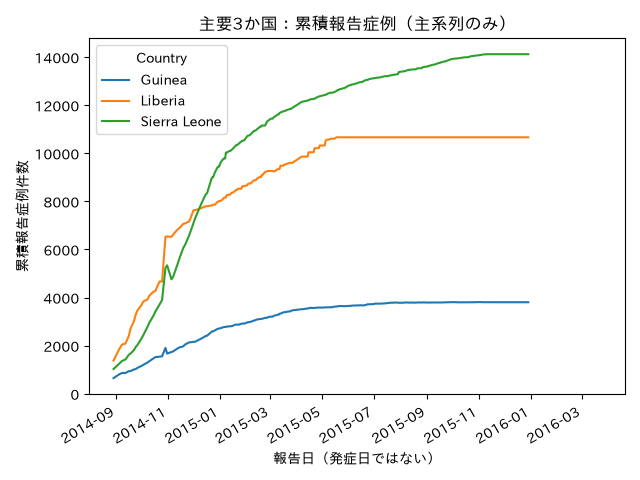

In [9]:
with phase('chart-main-cases'):
    chart_frame = primary[primary['Country'].isin(['Guinea', 'Liberia', 'Sierra Leone'])].pivot(index='Date',columns='Country',values='cases')
    gap_dates = [chart_frame.index[i-1]+pd.Timedelta(days=1) for i in range(1,len(chart_frame.index)) if (chart_frame.index[i]-chart_frame.index[i-1]).days>21]
    chart_frame = chart_frame.reindex(chart_frame.index.union(pd.DatetimeIndex(gap_dates))).sort_index()
    with warnings.catch_warnings(record=True) as chart_warnings:
        warnings.simplefilter('always')
        png = visualization.render_chart(chart_frame,kind='line',title='主要3か国：累積報告症例（主系列のみ）',xlabel='報告日（発症日ではない）',ylabel='累積報告症例件数')
    glyph_warnings = [str(w.message) for w in chart_warnings if 'Glyph' in str(w.message)]
    if glyph_warnings:
        raise RuntimeError('図に欠落文字がある:'+str(glyph_warnings))
    image_output = visualization.build_image_output(png)
    display(image_output['data'],raw=True)
    with phase('save-chart-main-cases',writing=True):
        (data_dir/'main-cases.png').write_bytes(png)
    print('視覚確認記録: 欠落文字警告0、タイトル/軸/凡例あり、累積値は非負、国名凡例を表示。欠測は補完せず線は観測点間の接続であり日次補間ではない。')


視覚確認記録: 欠落文字警告0、タイトル/軸/凡例あり、累積値は非負、国名凡例を表示。欠測は補完せず線は観測点間の接続であり日次補間ではない。


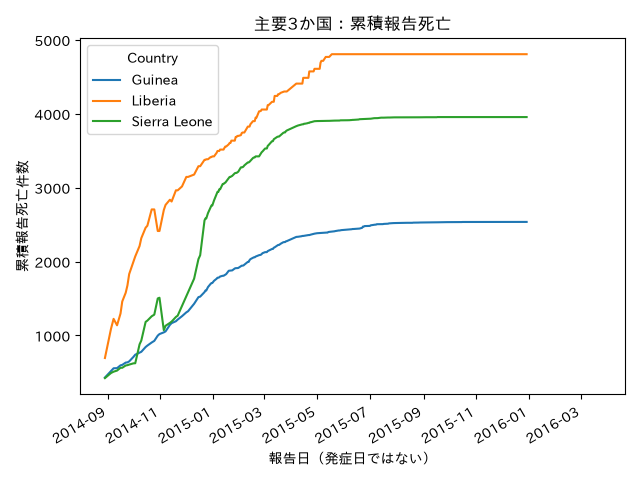

In [10]:
with phase('chart-main-deaths'):
    chart_frame = primary[primary['Country'].isin(['Guinea', 'Liberia', 'Sierra Leone'])].pivot(index='Date',columns='Country',values='deaths')
    gap_dates = [chart_frame.index[i-1]+pd.Timedelta(days=1) for i in range(1,len(chart_frame.index)) if (chart_frame.index[i]-chart_frame.index[i-1]).days>21]
    chart_frame = chart_frame.reindex(chart_frame.index.union(pd.DatetimeIndex(gap_dates))).sort_index()
    with warnings.catch_warnings(record=True) as chart_warnings:
        warnings.simplefilter('always')
        png = visualization.render_chart(chart_frame,kind='line',title='主要3か国：累積報告死亡',xlabel='報告日（発症日ではない）',ylabel='累積報告死亡件数')
    glyph_warnings = [str(w.message) for w in chart_warnings if 'Glyph' in str(w.message)]
    if glyph_warnings:
        raise RuntimeError('図に欠落文字がある:'+str(glyph_warnings))
    image_output = visualization.build_image_output(png)
    display(image_output['data'],raw=True)
    with phase('save-chart-main-deaths',writing=True):
        (data_dir/'main-deaths.png').write_bytes(png)
    print('視覚確認記録: 欠落文字警告0、タイトル/軸/凡例あり、累積値は非負、国名凡例を表示。欠測は補完せず線は観測点間の接続であり日次補間ではない。')


視覚確認記録: 欠落文字警告0、タイトル/軸/凡例あり、累積値は非負、国名凡例を表示。欠測は補完せず線は観測点間の接続であり日次補間ではない。


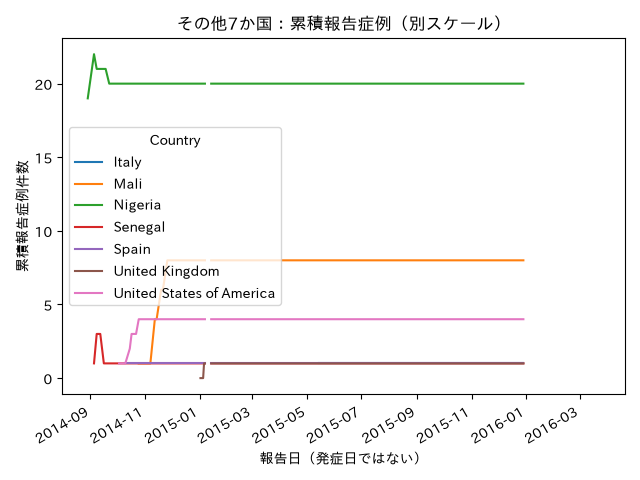

In [11]:
with phase('chart-other-cases'):
    chart_frame = primary[primary['Country'].isin(['Italy', 'Mali', 'Nigeria', 'Senegal', 'Spain', 'United Kingdom', 'United States of America'])].pivot(index='Date',columns='Country',values='cases')
    gap_dates = [chart_frame.index[i-1]+pd.Timedelta(days=1) for i in range(1,len(chart_frame.index)) if (chart_frame.index[i]-chart_frame.index[i-1]).days>21]
    chart_frame = chart_frame.reindex(chart_frame.index.union(pd.DatetimeIndex(gap_dates))).sort_index()
    with warnings.catch_warnings(record=True) as chart_warnings:
        warnings.simplefilter('always')
        png = visualization.render_chart(chart_frame,kind='line',title='その他7か国：累積報告症例（別スケール）',xlabel='報告日（発症日ではない）',ylabel='累積報告症例件数')
    glyph_warnings = [str(w.message) for w in chart_warnings if 'Glyph' in str(w.message)]
    if glyph_warnings:
        raise RuntimeError('図に欠落文字がある:'+str(glyph_warnings))
    image_output = visualization.build_image_output(png)
    display(image_output['data'],raw=True)
    with phase('save-chart-other-cases',writing=True):
        (data_dir/'other-cases.png').write_bytes(png)
    print('視覚確認記録: 欠落文字警告0、タイトル/軸/凡例あり、累積値は非負、国名凡例を表示。欠測は補完せず線は観測点間の接続であり日次補間ではない。')


### Insight 1：収録主系列の報告負担は主要3か国に集中

2016-03-23の10か国主系列に対してGuinea・Liberia・Sierra Leoneの症例シェアは99.87424898700573%。主3系列の累積報告症例合計は28,592、死亡合計は11,297。症例数の順位はSierra Leone > Liberia > Guinea、死亡数はLiberia > Sierra Leone > Guinea。2付き系列は別枠であり、これらを流行全体の最終総数・未報告例を含む負担とは呼ばない。

```evidence
{"execution_count":8,"cited_value":"99.87424898700573","claim_type":"descriptive"}
```

### Insight 2：報告値は単調な実際の感染数ではない

国別主系列には症例の負差分が51区間、死亡の負差分が7区間ある。累積報告値の減少は遡及改訂・分類変更等の候補であり、負の新規感染として解釈しない。大きな増加も同様に報告のまとめ反映を含み得る。

```evidence
{"execution_count":8,"cited_value":"51","claim_type":"descriptive"}
```

### Insight 3：末尾の横ばいから連続的なゼロ発生を推定できない

主10か国はいずれも2015-12-29から2016-03-23まで85日間の観測間隔がある。両端の主系列が同じ値でも、その間の流行動向・追加報告・再燃はこのCSVだけでは分からない。日付は報告スナップショット日と推定しており、発症日ではない。

```evidence
{"execution_count":8,"cited_value":"85.0","claim_type":"descriptive"}
```

## 反復依頼履歴

### 反復1（初回分析を読み直した後に選定）

**選定理由:** 同一国日付の211行が重複し、詳細版には別系列ラベルが残る。国別総数と清掃済み版の信頼性を左右するため、他の解析より先に解決範囲を調べる。

**追加依頼文（原文）:**

清掃済みCSVの国日付重複と詳細版のGuinea 2・Liberia 2が、国別総数・主要3か国の順位にどれほど影響するか確認してください。元ラベルを保全して清掃済み版との対応を調べ、2付き系列を加算しない場合と、重複しないと仮定して加算する場合、集計終点を2015年12月と2016年3月に変える場合を感度分析してください。加算可能性が未確認であることは残してください。

In [12]:
with phase('iteration-1-strata-sensitivity'):
    clean_named = raw.rename(columns={raw.columns[2]:'cases',raw.columns[3]:'deaths'}).copy()
    clean_named['Date'] = pd.to_datetime(clean_named['Date'])
    clean_named['raw_row'] = clean_named.index
    main_lookup = primary[['Country','Date','cases','deaths']]
    checked = clean_named.merge(main_lookup,on=['Country','Date'],how='left',suffixes=('_clean','_detail'),validate='many_to_one')
    match_cases = np.isclose(checked['cases_clean'],checked['cases_detail'],equal_nan=True)
    match_deaths = np.isclose(checked['deaths_clean'],checked['deaths_detail'],equal_nan=True)
    clean_mismatches = checked[~(match_cases & match_deaths)].copy()
    print('清掃済み版と詳細主系列で両値が一致しない行:',len(clean_mismatches))
    display(clean_mismatches.tail(8))
    print('2付き系列最新値:', recurrence.groupby('Country').tail(1).to_dict('records'))
    # Guinea 2を単に国名正規化したときの一致先と、清掃済み版に保持された国名を照合する。
    stratum_mapping = []
    for row in recurrence.itertuples():
        found = clean_named[(clean_named['Date']==row.Date) & (clean_named['cases']==row.cases) & (clean_named['deaths']==row.deaths)]
        stratum_mapping.append({'source_label':row.Country,'Date':row.Date,'cases':row.cases,'deaths':row.deaths,'cleaned_labels':sorted(found['Country'].unique().tolist())})
    mapping_table = pd.DataFrame(stratum_mapping)
    display(mapping_table.head(1))
    display(mapping_table.tail(8))
    def totals_spec(cutoff,strata,metric='cases'):
        latest_primary = primary[primary['Date']<=pd.Timestamp(cutoff)].sort_values('Date').groupby('Country').tail(1)
        main = latest_primary[latest_primary['Country'].isin(main3)].set_index('Country')[metric].copy()
        if strata=='add_if_disjoint':
            extra = recurrence[recurrence['Date']<=pd.Timestamp(cutoff)].sort_values('Date').groupby('Country').tail(1)
            for row in extra.itertuples():
                country = row.Country.removesuffix(' 2')
                main.loc[country] += getattr(row,metric)
        return main
    strata_plan = sensitivity.SensitivityPlan(parameter_grid={'cutoff':['2016-03-23','2015-12-29'],'strata':['main_only','add_if_disjoint']},max_runs=4)
    strata_case_report = sensitivity.run_sensitivity(strata_plan,lambda **spec: totals_spec(**spec,metric='cases').sum(),stability_tolerance=0.005)
    strata_death_report = sensitivity.run_sensitivity(strata_plan,lambda **spec: totals_spec(**spec,metric='deaths').sum(),stability_tolerance=0.005)
    ranks = [{'specification':spec,'case_rank':list(totals_spec(**spec).sort_values(ascending=False).index),'death_rank':list(totals_spec(**spec,metric='deaths').sort_values(ascending=False).index)} for spec in strata_plan.specifications()]
    iter1_metrics = {'cleaned_mismatch_rows':len(clean_mismatches),'cases_min':min(r.value for r in strata_case_report.results),'cases_max':max(r.value for r in strata_case_report.results),'deaths_min':min(r.value for r in strata_death_report.results),'deaths_max':max(r.value for r in strata_death_report.results),'cases_stable':strata_case_report.stable,'cases_max_relative_deviation':strata_case_report.max_relative_deviation,'deaths_stable':strata_death_report.stable,'deaths_max_relative_deviation':strata_death_report.max_relative_deviation,'case_rank_unchanged':all(r['case_rank']==['Sierra Leone','Liberia','Guinea'] for r in ranks),'death_rank_unchanged':all(r['death_rank']==['Liberia','Sierra Leone','Guinea'] for r in ranks),'tolerance':0.005}
    display({'text/plain':json.dumps(iter1_metrics,ensure_ascii=False,sort_keys=True)},raw=True)
    print('4仕様の全結果:',json.dumps({'cases':asdict(strata_case_report),'deaths':asdict(strata_death_report),'ranks':ranks},ensure_ascii=False))
    save_json('iteration-1-results.json',{'metrics':iter1_metrics,'cases':asdict(strata_case_report),'deaths':asdict(strata_death_report),'ranks':ranks})
    with phase('write-iteration-1-detail',writing=True):
        clean_mismatches.to_csv(data_dir/'cleaned-detail-mismatches.csv',index=False)
        mapping_table.to_csv(data_dir/'stratum-cleaned-label-mapping.csv',index=False)


清掃済み版と詳細主系列で両値が一致しない行: 106
2付き系列最新値: [{'Country': 'Guinea 2', 'Date': Timestamp('2016-03-23 00:00:00'), 'cases': 5.0, 'deaths': 4.0}, {'Country': 'Liberia 2', 'Date': Timestamp('2016-03-23 00:00:00'), 'cases': 9.0, 'deaths': 3.0}]
4仕様の全結果: {"cases": {"results": [{"specification": {"cutoff": "2016-03-23", "strata": "main_only"}, "value": 28592.0}, {"specification": {"cutoff": "2016-03-23", "strata": "add_if_disjoint"}, "value": 28606.0}, {"specification": {"cutoff": "2015-12-29", "strata": "main_only"}, "value": 28592.0}, {"specification": {"cutoff": "2015-12-29", "strata": "add_if_disjoint"}, "value": 28601.0}], "baseline_value": 28592.0, "stable": true, "max_relative_deviation": 0.00048964745383324}, "deaths": {"results": [{"specification": {"cutoff": "2016-03-23", "strata": "main_only"}, "value": 11297.0}, {"specification": {"cutoff": "2016-03-23", "strata": "add_if_disjoint"}, "value": 11304.0}, {"specification": {"cutoff": "2015-12-29", "strata": "main_only"}, "value": 11297.0}, {"

,Country,Date,cases_clean,deaths_clean,raw_row,cases_detail,deaths_detail
2415,Liberia,2015-12-15,9.0,3.0,2415,10666.0,4806.0
2428,Liberia,2015-12-16,9.0,3.0,2428,10666.0,4806.0
2429,Liberia,2015-12-17,9.0,3.0,2429,10666.0,4806.0
2443,Liberia,2015-12-22,9.0,3.0,2443,10666.0,4806.0
2459,Liberia,2015-12-23,9.0,3.0,2459,10666.0,4806.0
2466,Liberia,2015-12-29,9.0,3.0,2466,10666.0,4806.0
2479,Liberia,2016-03-23,9.0,3.0,2479,10666.0,4806.0
2482,Liberia,2016-03-23,5.0,4.0,2482,10666.0,4806.0


,source_label,Date,cases,deaths,cleaned_labels
0,Guinea 2,2016-03-23,5.0,4.0,[Liberia]


,source_label,Date,cases,deaths,cleaned_labels
98,Liberia 2,2015-12-11,9.0,3.0,[Liberia]
99,Liberia 2,2015-12-15,9.0,3.0,[Liberia]
100,Liberia 2,2015-12-16,9.0,3.0,[Liberia]
101,Liberia 2,2015-12-17,9.0,3.0,[Liberia]
102,Liberia 2,2015-12-22,9.0,3.0,[Liberia]
103,Liberia 2,2015-12-23,9.0,3.0,[Liberia]
104,Liberia 2,2015-12-29,9.0,3.0,[Liberia]
105,Liberia 2,2016-03-23,9.0,3.0,[Liberia]


{"case_rank_unchanged": true, "cases_max": 28606.0, "cases_max_relative_deviation": 0.00048964745383324, "cases_min": 28592.0, "cases_stable": true, "cleaned_mismatch_rows": 106, "death_rank_unchanged": true, "deaths_max": 11304.0, "deaths_max_relative_deviation": 0.0006196335310259361, "deaths_min": 11297.0, "deaths_stable": true, "tolerance": 0.005}

### 反復1の結果：清掃済み版のラベル喪失に注意

清掃済み版の106行は詳細版の同一国日付の主系列値と一致しなかった。別系列を主系列として混入させることを避けるため、詳細版ラベル保全を維持する。Guinea 2の2016-03-23の5症例・4死亡は清掃済み版でLiberia名の行に一致し、清掃済み版だけでは国別集計の誤りを起こし得る（対応表CSV参照）。これは取得データ/上流変換の問題でありJupytermindの不具合と分類しない。

```evidence
{"execution_count":12,"cited_value":"106","claim_type":"descriptive"}
```

### 反復1の結果：限定した系列・終点選択には順位が安定

2終点×2系列処理の4仕様で、主要3国の症例合計は28,592–28,606、死亡合計は11,297–11,304。症例のmax_relative_deviation=0.00048964745383324、死亡は0.0006196335310259361で、事前閾値0.005に対するstableはいずれもTrue。症例順位・死亡順位は変わらなかった。これは試した有限仕様の安定性であり、不確実性区間や真の流行最終総数ではない。残る限界は2付き系列が重複なしで加算可能か確認できないこと。

```evidence
{"execution_count":12,"cited_value":"0.00048964745383324","claim_type":"descriptive"}
```

### 反復2

**選定理由:** 累積線の鈍化は感染数の鈍化と同一ではなく、51/7の負差分・不規則間隔・85日空白がある。観測される純報告増加の方向と大きさを分けて検証する。

**追加依頼文（原文）:**

主要3か国の累積報告値は2014年後半に増え、2015年後半に横ばいに近づいて見えます。この変化が報告間隔の不規則さや負の改訂の扱いによる見かけではないか調べてください。観測区間の長さで重み付けした純報告増分を前半と後半で比較し、最大許容報告間隔を7日と14日に変え、負差分保持とゼロクリップを感度仕様として比較してください。週末の観測スナップショット差分も図示し、真の新規感染数や流行終息とは呼ばないでください。

In [13]:
with phase('iteration-2-temporal-sensitivity'):
    intervals = primary[primary['Country'].isin(main3)].copy()
    intervals['start_date'] = intervals['Date']-pd.to_timedelta(intervals['days_between'],unit='D')
    periods = {'2014_late':(pd.Timestamp('2014-08-29'),pd.Timestamp('2014-12-31')),'2015_H2':(pd.Timestamp('2015-07-01'),pd.Timestamp('2015-12-29'))}
    def interval_selection(period,gap_limit):
        start,end = periods[period]
        return intervals[(intervals['start_date']>=start)&(intervals['Date']<=end)&intervals['days_between'].between(1,gap_limit)]
    period_rows = []
    for period in periods:
        part = interval_selection(period,7)
        for country in main3:
            sub = part[part['Country']==country]
            if sub.empty:
                raise ValueError('比較区間に観測がない:'+country+period)
            period_rows.append({'period':period,'Country':country,'interval_count':len(sub),'observed_country_days':float(sub['days_between'].sum()),'window_days':(periods[period][1]-periods[period][0]).days,'net_cases':float(sub['delta_cases'].sum()),'net_deaths':float(sub['delta_deaths'].sum()),'net_cases_per_day':float(sub['delta_cases'].sum()/sub['days_between'].sum()),'net_deaths_per_day':float(sub['delta_deaths'].sum()/sub['days_between'].sum()),'negative_case_intervals':int((sub['delta_cases']<0).sum()),'negative_death_intervals':int((sub['delta_deaths']<0).sum())})
    period_table = pd.DataFrame(period_rows)
    display(period_table)
    def late_early_ratio(gap_limit,negative_policy,metric):
        rates = []
        for period in periods:
            sub = interval_selection(period,gap_limit)
            col = 'delta_'+metric
            if sub[col].isna().any():
                raise ValueError('主要3国比較区間に欠測差分がある')
            delta = sub[col] if negative_policy=='retain' else sub[col].clip(lower=0)
            exposure = sub['days_between'].sum()
            if exposure<=0:
                raise ValueError('有効観測日数なし')
            rates.append(float(delta.sum()/exposure))
        if rates[0]<=0:
            raise ValueError('前半純増加率が非正')
        return rates[1]/rates[0]
    temporal_plan = sensitivity.SensitivityPlan(parameter_grid={'gap_limit':[7,14],'negative_policy':['retain','clip_zero']},max_runs=4)
    temporal_case_report = sensitivity.run_sensitivity(temporal_plan,lambda **spec:late_early_ratio(**spec,metric='cases'),stability_tolerance=0.2)
    temporal_death_report = sensitivity.run_sensitivity(temporal_plan,lambda **spec:late_early_ratio(**spec,metric='deaths'),stability_tolerance=0.2)
    # 欠測週はNaNのまま。主要3国が同じ週で揃う場合だけ合計する。
    observed = primary[primary['Country'].isin(main3)&(primary['Date']<=pd.Timestamp('2015-12-29'))]
    weekly_cases = observed.pivot(index='Date',columns='Country',values='cases').resample('W-SUN').last()
    weekly_deaths = observed.pivot(index='Date',columns='Country',values='deaths').resample('W-SUN').last()
    weekly_net = pd.DataFrame({'報告症例の純変化':weekly_cases.diff().sum(axis=1,min_count=3),'報告死亡の純変化':weekly_deaths.diff().sum(axis=1,min_count=3)})
    display(weekly_net.dropna().head(8))
    iter2_metrics = {'case_ratio_late_early_baseline':temporal_case_report.baseline_value,'case_ratio_min':min(r.value for r in temporal_case_report.results),'case_ratio_max':max(r.value for r in temporal_case_report.results),'case_direction_lower_all':all(r.value<1 for r in temporal_case_report.results),'case_stable':temporal_case_report.stable,'case_max_relative_deviation':temporal_case_report.max_relative_deviation,'death_ratio_late_early_baseline':temporal_death_report.baseline_value,'death_ratio_min':min(r.value for r in temporal_death_report.results),'death_ratio_max':max(r.value for r in temporal_death_report.results),'death_direction_lower_all':all(r.value<1 for r in temporal_death_report.results),'death_stable':temporal_death_report.stable,'death_max_relative_deviation':temporal_death_report.max_relative_deviation,'tolerance':0.2}
    display({'text/plain':json.dumps(iter2_metrics,ensure_ascii=False,sort_keys=True)},raw=True)
    print('感度全結果:',json.dumps({'cases':asdict(temporal_case_report),'deaths':asdict(temporal_death_report)},ensure_ascii=False))
    save_json('iteration-2-results.json',{'metrics':iter2_metrics,'cases':asdict(temporal_case_report),'deaths':asdict(temporal_death_report)})
    with phase('write-iteration-2-tables',writing=True):
        period_table.to_csv(data_dir/'period-net-reporting-rates.csv',index=False)
        weekly_net.to_csv(data_dir/'weekly-snapshot-net-changes.csv')
    print('ゼロクリップは改訂無視の影響を測るだけの比較仕様で、主分析には採用しない。週は観測スナップショットの区切りであり、7日間の発症コホートではない。')


感度全結果: {"cases": {"results": [{"specification": {"gap_limit": 7, "negative_policy": "retain"}, "value": 0.04314033162080581}, {"specification": {"gap_limit": 7, "negative_policy": "clip_zero"}, "value": 0.04423952806573195}, {"specification": {"gap_limit": 14, "negative_policy": "retain"}, "value": 0.04314033162080581}, {"specification": {"gap_limit": 14, "negative_policy": "clip_zero"}, "value": 0.04423952806573195}], "baseline_value": 0.04314033162080581, "stable": true, "max_relative_deviation": 0.02547955483021875}, "deaths": {"results": [{"specification": {"gap_limit": 7, "negative_policy": "retain"}, "value": 0.00831516097343468}, {"specification": {"gap_limit": 7, "negative_policy": "clip_zero"}, "value": 0.007338812077833835}, {"specification": {"gap_limit": 14, "negative_policy": "retain"}, "value": 0.00831516097343468}, {"specification": {"gap_limit": 14, "negative_policy": "clip_zero"}, "value": 0.007338812077833835}], "baseline_value": 0.00831516097343468, "stable": true, "

,period,Country,interval_count,observed_country_days,window_days,net_cases,net_deaths,net_cases_per_day,net_deaths_per_day,negative_case_intervals,negative_death_intervals
0,2014_late,Guinea,37,124.0,124,2059.0,1279.0,16.604839,10.314516,2,0
1,2014_late,Liberia,37,124.0,124,6640.0,2729.0,53.548387,22.008065,1,4
2,2014_late,Sierra Leone,37,124.0,124,8420.0,2336.0,67.903226,18.838710,1,1
3,2015_H2,Guinea,105,181.0,181,75.0,54.0,0.414365,0.298343,28,0
4,2015_H2,Liberia,105,181.0,181,0.0,0.0,0.000000,0.000000,0,0
5,2015_H2,Sierra Leone,105,181.0,181,1003.0,23.0,5.541436,0.127072,0,0


,報告症例の純変化,報告死亡の純変化
Date,,
2014-09-07,892.0,551.0
2014-09-14,422.0,121.0
2014-09-21,959.0,404.0
2014-09-28,1228.0,461.0
2014-10-05,917.0,348.0
2014-10-12,906.0,593.0
2014-10-19,815.0,522.0
2014-10-26,923.0,366.0


{"case_direction_lower_all": true, "case_max_relative_deviation": 0.02547955483021875, "case_ratio_late_early_baseline": 0.04314033162080581, "case_ratio_max": 0.04423952806573195, "case_ratio_min": 0.04314033162080581, "case_stable": true, "death_direction_lower_all": true, "death_max_relative_deviation": 0.11741791875347812, "death_ratio_late_early_baseline": 0.00831516097343468, "death_ratio_max": 0.00831516097343468, "death_ratio_min": 0.007338812077833835, "death_stable": true, "tolerance": 0.2}

監査メモ: 負差分を保持、長期空白は不掲載、2系列凡例あり、欠落文字0。急増の頂点を感染ピークと断定しない。


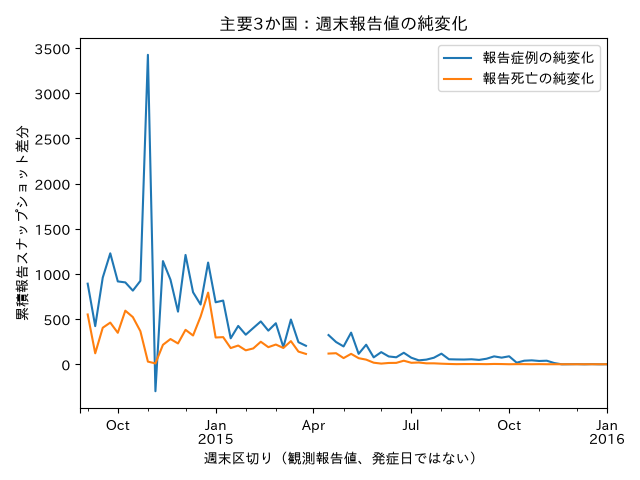

In [14]:
with phase('chart-weekly-net-change'):
    with warnings.catch_warnings(record=True) as chart_warnings:
        warnings.simplefilter('always')
        weekly_png = visualization.render_chart(weekly_net,kind='line',title='主要3か国：週末報告値の純変化',xlabel='週末区切り（観測報告値、発症日ではない）',ylabel='累積報告スナップショット差分')
    glyph_warnings = [str(w.message) for w in chart_warnings if 'Glyph' in str(w.message)]
    if glyph_warnings:
        raise RuntimeError('欠落文字:'+str(glyph_warnings))
    weekly_output = visualization.build_image_output(weekly_png)
    display(weekly_output['data'],raw=True)
    with phase('save-weekly-chart',writing=True):
        (data_dir/'weekly-net-change.png').write_bytes(weekly_png)
    print('監査メモ: 負差分を保持、長期空白は不掲載、2系列凡例あり、欠落文字0。急増の頂点を感染ピークと断定しない。')


### 反復2の結果：収録区間の純報告増加率は後半に低い

2014-08-29〜12-31と2015-07-01〜12-29の主要3国の観測国日数で重み付けした純報告増加率を比較すると、後半/前半は症例0.04314033162080581、死亡0.00831516097343468。許容間隔7/14日×負差分保持/ゼロクリップの4仕様すべてで比は1未満。閾値0.2に対し症例stable=True・max_relative_deviation=0.02547955483021875、死亡stable=True・max_relative_deviation=0.11741791875347812。報告値の増加鈍化の方向はこの範囲で安定するが、発症日別の感染減少率・介入効果・流行終息の証拠ではない。ゼロクリップは感度比較だけで主分析は符号を保持。7/14日の結果が同じなのは、対象期間の全観測間隔が7日以下だからであり独立な4データの確認ではない。残る限界は捕捉率・症例分類・報告バッチの変化。

```evidence
{"execution_count":13,"cited_value":"0.04314033162080581","claim_type":"descriptive"}
```

### 反復3

**選定理由:** 同じ国順位でも確定例の比率が異なると検査・分類の違いで順位が変わる。総症例だけの順位を「感染の多さ」と一般化しないため、定義変更を最後の結論重要点として検証する。

**追加依頼文（原文）:**

国別の報告症例順位が症例定義に依存していないか確認してください。詳細版の確定・可能性・疑い例の内訳を同じ報告日で照合し、総症例と確定例のみを、2015年12月29日と2016年3月23日の二つの終点で比較してください。特にLiberiaとGuineaの順位および比率への影響を感度分析し、確定死亡の欠測がある国では同じ定義の死亡/症例比率を推定しないでください。

In [15]:
with phase('iteration-3-case-definition-sensitivity'):
    case_definitions = {
        'total':case_indicator,
        'confirmed':'Cumulative number of confirmed Ebola cases',
        'probable':'Cumulative number of probable Ebola cases',
        'suspected':'Cumulative number of suspected Ebola cases'}
    case_parts = detail_clean[detail_clean['Country'].isin(main3)&detail_clean['Indicator'].isin(case_definitions.values())].copy()
    case_parts['Date'] = pd.to_datetime(case_parts['Date'],format='%Y-%m-%d')
    if case_parts.duplicated(['Country','Date','Indicator']).any():
        raise ValueError('内訳に同一キーの複数行がある')
    parts_wide = case_parts.pivot(index=['Country','Date'],columns='Indicator',values='value').rename(columns={v:k for k,v in case_definitions.items()}).reset_index()
    parts_wide.columns.name = None
    parts_wide['component_sum'] = parts_wide[['confirmed','probable','suspected']].sum(axis=1,min_count=3)
    parts_wide['sum_minus_total'] = parts_wide['component_sum']-parts_wide['total']
    complete_components = parts_wide.dropna(subset=['total','confirmed','probable','suspected'])
    component_mismatches = complete_components[complete_components['sum_minus_total']!=0]
    print('比較可能な内訳行:',len(complete_components),'内訳合計と総数の不一致:',len(component_mismatches))
    display(component_mismatches.head(10))
    endpoint_parts = parts_wide[parts_wide['Date'].isin([pd.Timestamp('2015-12-29'),pd.Timestamp('2016-03-23')])].copy()
    endpoint_parts['confirmed_share_pct'] = 100*endpoint_parts['confirmed']/endpoint_parts['total']
    endpoint_parts['suspected_share_pct'] = 100*endpoint_parts['suspected']/endpoint_parts['total']
    display(endpoint_parts.sort_values(['Date','total'],ascending=[True,False]))
    def definition_ratio(cutoff,definition):
        end = parts_wide[parts_wide['Date']==pd.Timestamp(cutoff)].set_index('Country')
        if set(end.index)!=set(main3) or end[definition].isna().any():
            raise ValueError('同日3国の症例定義が揃わない')
        return float(end.loc['Liberia',definition]/end.loc['Guinea',definition])
    definition_plan = sensitivity.SensitivityPlan(parameter_grid={'cutoff':['2016-03-23','2015-12-29'],'definition':['total','confirmed']},max_runs=4)
    definition_report = sensitivity.run_sensitivity(definition_plan,definition_ratio,stability_tolerance=0.2)
    definition_ranks = []
    for spec in definition_plan.specifications():
        end = parts_wide[parts_wide['Date']==pd.Timestamp(spec['cutoff'])].set_index('Country')
        definition_ranks.append({'specification':spec,'rank':list(end[spec['definition']].sort_values(ascending=False).index)})
    confirmed_death_indicator = 'Cumulative number of confirmed Ebola deaths'
    confirmed_deaths = detail_clean[(detail_clean['Indicator']==confirmed_death_indicator)&(detail_clean['Date']=='2016-03-23')&detail_clean['Country'].isin(main3)][['Country','value']].set_index('Country').reindex(main3)
    display(confirmed_deaths.rename(columns={'value':'reported_confirmed_deaths'}))
    missing_confirmed_death_countries = list(confirmed_deaths.index[confirmed_deaths['value'].isna()])
    iter3_metrics = {'component_complete_rows':len(complete_components),'component_mismatch_rows':len(component_mismatches),'liberia_guinea_ratio_total':definition_report.baseline_value,'liberia_guinea_ratio_confirmed':definition_ratio('2016-03-23','confirmed'),'stable':definition_report.stable,'max_relative_deviation':definition_report.max_relative_deviation,'tolerance':0.2,'ranks':definition_ranks,'confirmed_deaths_missing_countries':missing_confirmed_death_countries}
    display({'text/plain':json.dumps(iter3_metrics,ensure_ascii=False,sort_keys=True)},raw=True)
    save_json('iteration-3-results.json',{'metrics':iter3_metrics,'sensitivity':asdict(definition_report)})
    with phase('write-case-definition-tables',writing=True):
        endpoint_parts.to_csv(data_dir/'endpoint-case-definitions.csv',index=False)
        component_mismatches.to_csv(data_dir/'case-component-mismatches.csv',index=False)
    final_definition_cases = endpoint_parts[endpoint_parts['Date']==pd.Timestamp('2016-03-23')].set_index('Country')[['confirmed','probable','suspected']].reindex(main3)
    print('残る限界:確定例のみは同じ総症例を測る別推定法ではなく、別のestimand。検査・症例定義・報告の国差を補正しない。Liberiaの確定死亡をゼロとみなさず、欠測のため同定義比率を比較しない。')


比較可能な内訳行: 776 内訳合計と総数の不一致: 6
残る限界:確定例のみは同じ総症例を測る別推定法ではなく、別のestimand。検査・症例定義・報告の国差を補正しない。Liberiaの確定死亡をゼロとみなさず、欠測のため同定義比率を比較しない。


,Country,Date,confirmed,total,probable,suspected,component_sum,sum_minus_total
39,Guinea,2015-01-05,2465.0,2769.0,280.0,26.0,2771.0,2.0
122,Guinea,2015-05-20,3201.0,3635.0,415.0,15.0,3631.0,-4.0
264,Liberia,2014-09-18,812.0,2710.0,1233.0,675.0,2720.0,10.0
298,Liberia,2015-01-05,3116.0,8115.0,1805.0,3198.0,8119.0,4.0
558,Sierra Leone,2015-01-06,7602.0,9780.0,287.0,1819.0,9708.0,-72.0
559,Sierra Leone,2015-01-07,7602.0,9780.0,287.0,1819.0,9708.0,-72.0


,Country,Date,confirmed,total,probable,suspected,component_sum,sum_minus_total,confirmed_share_pct,suspected_share_pct
775,Sierra Leone,2015-12-29,8704.0,14122.0,287.0,5131.0,14122.0,0.0,61.634329,36.333381
516,Liberia,2015-12-29,3151.0,10666.0,1879.0,5636.0,10666.0,0.0,29.542471,52.840803
257,Guinea,2015-12-29,3351.0,3804.0,453.0,0.0,3804.0,0.0,88.091483,0.000000
776,Sierra Leone,2016-03-23,8704.0,14122.0,287.0,5131.0,14122.0,0.0,61.634329,36.333381
517,Liberia,2016-03-23,3151.0,10666.0,1879.0,5636.0,10666.0,0.0,29.542471,52.840803
258,Guinea,2016-03-23,3351.0,3804.0,453.0,0.0,3804.0,0.0,88.091483,0.000000


,reported_confirmed_deaths
Country,
Guinea,2083.0
Liberia,NaN
Sierra Leone,3589.0


{"component_complete_rows": 776, "component_mismatch_rows": 6, "confirmed_deaths_missing_countries": ["Liberia"], "liberia_guinea_ratio_confirmed": 0.9403163234855267, "liberia_guinea_ratio_total": 2.8038906414300735, "max_relative_deviation": 0.6646387310576651, "ranks": [{"rank": ["Sierra Leone", "Liberia", "Guinea"], "specification": {"cutoff": "2016-03-23", "definition": "total"}}, {"rank": ["Sierra Leone", "Guinea", "Liberia"], "specification": {"cutoff": "2016-03-23", "definition": "confirmed"}}, {"rank": ["Sierra Leone", "Liberia", "Guinea"], "specification": {"cutoff": "2015-12-29", "definition": "total"}}, {"rank": ["Sierra Leone", "Guinea", "Liberia"], "specification": {"cutoff": "2015-12-29", "definition": "confirmed"}}], "stable": false, "tolerance": 0.2}

図の凡例:confirmed=確定、probable=可能性、suspected=疑い。別系列を加算しない。3国の内訳合計は同日総症例に一致。


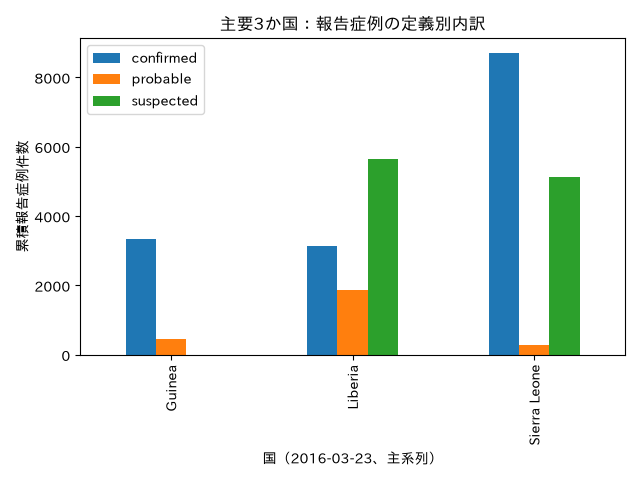

In [16]:
with phase('chart-case-definitions'):
    with warnings.catch_warnings(record=True) as chart_warnings:
        warnings.simplefilter('always')
        definition_png = visualization.render_chart(final_definition_cases,kind='bar',title='主要3か国：報告症例の定義別内訳',xlabel='国（2016-03-23、主系列）',ylabel='累積報告症例件数')
    if any('Glyph' in str(w.message) for w in chart_warnings):
        raise RuntimeError('内訳図で文字欠落')
    definition_output = visualization.build_image_output(definition_png)
    display(definition_output['data'],raw=True)
    with phase('save-definition-chart',writing=True):
        (data_dir/'case-definition-components.png').write_bytes(definition_png)
    print('図の凡例:confirmed=確定、probable=可能性、suspected=疑い。別系列を加算しない。3国の内訳合計は同日総症例に一致。')


### 反復3の結果：国順位は症例定義を変えると不安定

2016-03-23の主系列では総症例がSierra Leone 14,122 > Liberia 10,666 > Guinea 3,804だが、確定例はSierra Leone 8,704 > Guinea 3,351 > Liberia 3,151。Liberia/Guinea比は総症例2.8038906414300735から確定例0.9403163234855267へ変わる。2終点×2定義でstable=False、max_relative_deviation=0.6646387310576651（閾値0.2）。総症例の順位は総症例という定義に限る。確定例は別のestimandであり、国ごとの検査能力・報告基準差は補正できない。Liberiaの確定死亡が欠測なので確定死亡/確定症例の国比較は行わない。

```evidence
{"execution_count":15,"cited_value":"0.6646387310576651","claim_type":"descriptive"}
```

### 反復3の品質確認：内訳と総数の不整合を保持

3分類が揃う776国日付のうち6行で確定+可能性+疑いの内訳合計と総症例が一致しなかった（差は-72〜+10）。終点2日では3か国とも合計が一致しており、この6行を自動修正せず出力CSVに残した。上流の転記・時点差・改訂等のどれによるかは独立資料なしでは確定できない。

```evidence
{"execution_count":15,"cited_value":"6","claim_type":"descriptive"}
```

## 使用したJupytermindモジュール

下の実行セルで、直接import・呼び出したモジュール/関数/使用目的を一覧にし、`../data/module-usage.json`にも保存する。`insight_engine.record_insight`とNotebook組立ての`enqueue_write`はJupyter MCP制御Notebook `benchmark/ebola-bootstrap-v020-exp-25.ipynb`で直接呼出した。最終セルも`enqueue_write`と`extract_cited_value`を直接使う。間接利用は含めない。`mcp_gateway`・`dataset_validation`・`stats_analysis`・統計的外れ値判定等の未使用理由は`feature-applicability.json`に記録する。

In [17]:
with phase('final-assumptions-and-applicability'):
    A = analysis_assumptions.Assumption
    reviewed_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={**assumption_manifest.analysis_scope,'iteration_count':3,'conclusion':'報告データの記述に限定。定義別順位を分離'},
        assumptions=(A('date-reporting','Dateは報告スナップショットと解釈するが正確な締切・発症日は未確認','assumed',impact_if_false='報告の時期と感染の時期を取り違える。発症時系列は結論から除外',conclusion_critical=True),A('strata-handling','主系列/加算仮定および2終点の4仕様で主3国の順位は変わらない','tested',evidence_cell=None,impact_if_false='国別順位に影響',conclusion_critical=True),A('strata-disjoint','2付き系列を主系列に重複なしで加算可能','assumed',impact_if_false='加算総数が二重計上になる。加算は感度上限シナリオだけ',conclusion_critical=False),A('temporal-direction','前後区間の純報告増加率の方向は間隔/改訂の4仕様で同じ','tested',conclusion_critical=True),A('definition-invariance','症例定義変更で国順位は不変','rejected',impact_if_false='総症例と確定症例の順位を同一視できないため別々に報告',conclusion_critical=False),A('report-only','真の感染数・致死率・介入効果を推定しない','verified',conclusion_critical=True),A('no-imputation','欠測・負の改訂・長期空白を補正しない','verified',conclusion_critical=True)),causal_scope='descriptive')
    final_assumption_findings = analysis_assumptions.check_manifest(reviewed_manifest)
    print('最終前提の指摘（全件）:',json.dumps([asdict(f) for f in final_assumption_findings],ensure_ascii=False))
    save_json('analysis-assumptions-final.json',asdict(reviewed_manifest))
    save_json('analysis-assumption-findings-final.json',[asdict(f) for f in final_assumption_findings])
    applicability = {
        'independent_dataset_validation':'未適用:同一Kaggle詳細版と清掃済み版は出所を共有し独立ではない。公開Plotly CSVはKaggle取得成功のため指定フォールバック条件が成立せず取得しない。',
        'validate_anomalies':'未適用:独立した国日付対応の参照データなし。上流由来の不整合かどうか確証なし。',
        'correlation_and_significance_tests':'未適用:累積系列は共通時間トレンドと自己相関があり、独立観測の相関検定では質問に答えない。',
        'z_score_outlier_detection':'未適用:非定常な累積値で大きい国を外れ値と除去する妥当性なし。意味検査と差分検査を使用。',
        'causal_estimation_or_epidemic_model':'未適用:発症日・報告遅延・人口分母・捕捉率・介入情報・識別戦略なし。',
        'mcp_gateway_run_and_record':'未使用:CLIホストの実MCP execute_cellで実行・出力を保存。カーネル内にPython MCPClientの参照が提供されないため、同一カーネル再入や偽のexecクライアントを作らない。準備・注釈の書込みはenqueue_writeで直列化。'}
    print('機能適用可否:',json.dumps(applicability,ensure_ascii=False,indent=2))
    save_json('feature-applicability.json',applicability)
    module_usage = [
        {'module':'ai_data_scientist.project_manager','functions':['resolve_project','ensure_notebook','ensure_data_dir','enqueue_write'],'purpose':'安定した保存先・データディレクトリ・Notebook書込みの直列化'},
        {'module':'ai_data_scientist.language_router','functions':['detect_language'],'purpose':'日本語応答・Notebook記述'},
        {'module':'ai_data_scientist.lifecycle','functions':['register_run','mark_execution_start','mark_execution_end','mark_write_start','mark_write_end','is_cancel_requested','mark_failed','mark_completed','get_run_status','wait_for_quiescence'],'purpose':'実行/書込み/完了・失敗と協調キャンセル確認'},
        {'module':'ai_data_scientist.ingestion','functions':['SourceSpec','ingest'],'purpose':'取得済みCSVのロードと行数上限'},
        {'module':'ai_data_scientist.cleaning','functions':['clean_dataset'],'purpose':'完全重複のみ除去し影響数を記録（0行削除）'},
        {'module':'ai_data_scientist.eda','functions':['explore'],'purpose':'型・記述統計・欠測・カテゴリ検査'},
        {'module':'ai_data_scientist.data_definition','functions':['FieldValue','build_manifest','DataDefinitionManifest.unresolved_fields'],'purpose':'確認済み/推定/報告/未知の定義を区別'},
        {'module':'ai_data_scientist.analysis_assumptions','functions':['Assumption','AnalysisAssumptionManifest','check_manifest'],'purpose':'分析前提・因果範囲・未解決リスク'},
        {'module':'ai_data_scientist.data_quality','functions':['detect_anomalies'],'purpose':'範囲/非欠測/ラベル/キー一意性の意味検査'},
        {'module':'ai_data_scientist.sensitivity','functions':['SensitivityPlan','SensitivityPlan.specifications','run_sensitivity'],'purpose':'仕様グリッドと安定性判定（反復ごと4仕様）'},
        {'module':'ai_data_scientist.visualization','functions':['render_chart','build_image_output'],'purpose':'日本語対応の5図とPNG MIME出力'},
        {'module':'ai_data_scientist.insight_engine','functions':['extract_cited_value','record_insight'],'purpose':'実出力から根拠引用。record_insightはMCP制御Notebookで直接呼出し、最終セルで引用の再紐付け'},
        {'module':'ai_data_scientist.notebook_audit','functions':['audit_notebook','audit_visual_outputs'],'purpose':'実行/根拠/図の監査と監査機能の限定再現検査'}]
    save_json('module-usage.json',module_usage)
    display(pd.DataFrame(module_usage))
    print('間接利用された内部モジュールは使用済みとして数えない。')


最終前提の指摘（全件）: [{"code": "unresolved_conclusion_critical_assumption", "severity": "warning", "message": "Conclusion-critical assumption 'date-reporting' has status 'assumed', not verified/tested.", "assumption_id": "date-reporting"}]
機能適用可否: {
  "independent_dataset_validation": "未適用:同一Kaggle詳細版と清掃済み版は出所を共有し独立ではない。公開Plotly CSVはKaggle取得成功のため指定フォールバック条件が成立せず取得しない。",
  "validate_anomalies": "未適用:独立した国日付対応の参照データなし。上流由来の不整合かどうか確証なし。",
  "correlation_and_significance_tests": "未適用:累積系列は共通時間トレンドと自己相関があり、独立観測の相関検定では質問に答えない。",
  "z_score_outlier_detection": "未適用:非定常な累積値で大きい国を外れ値と除去する妥当性なし。意味検査と差分検査を使用。",
  "causal_estimation_or_epidemic_model": "未適用:発症日・報告遅延・人口分母・捕捉率・介入情報・識別戦略なし。",
  "mcp_gateway_run_and_record": "未使用:CLIホストの実MCP execute_cellで実行・出力を保存。カーネル内にPython MCPClientの参照が提供されないため、同一カーネル再入や偽のexecクライアントを作らない。準備・注釈の書込みはenqueue_writeで直列化。"
}
間接利用された内部モジュールは使用済みとして数えない。


,module,functions,purpose
0,ai_data_scientist.project_manager,"[resolve_project, ensure_notebook, ensure_data...",安定した保存先・データディレクトリ・Notebook書込みの直列化
1,ai_data_scientist.language_router,[detect_language],日本語応答・Notebook記述
2,ai_data_scientist.lifecycle,"[register_run, mark_execution_start, mark_exec...",実行/書込み/完了・失敗と協調キャンセル確認
3,ai_data_scientist.ingestion,"[SourceSpec, ingest]",取得済みCSVのロードと行数上限
4,ai_data_scientist.cleaning,[clean_dataset],完全重複のみ除去し影響数を記録（0行削除）
5,ai_data_scientist.eda,[explore],型・記述統計・欠測・カテゴリ検査
6,ai_data_scientist.data_definition,"[FieldValue, build_manifest, DataDefinitionMan...",確認済み/推定/報告/未知の定義を区別
7,ai_data_scientist.analysis_assumptions,"[Assumption, AnalysisAssumptionManifest, check...",分析前提・因果範囲・未解決リスク
8,ai_data_scientist.data_quality,[detect_anomalies],範囲/非欠測/ラベル/キー一意性の意味検査
9,ai_data_scientist.sensitivity,"[SensitivityPlan, SensitivityPlan.specificatio...",仕様グリッドと安定性判定（反復ごと4仕様）


## Jupytermind改善候補

2件を下のセルで最小再現し、分類・再現条件・期待/実際の挙動・影響・回避策・関連セル/ログを構造化して保存する。既定描画のラベル切れはautolayoutで回避し、全図を再描画する。メタデータのない図の監査未検証は明示的メタデータと目視で補う。上流データ問題、Kaggle API、CLI/MCP Notebook準備、ベンチマークランナーの問題とは区別する。

In [18]:
with phase('jupytermind-improvement-reproduction'):
    import matplotlib
    import matplotlib.pyplot as plt
    # 実際に使った図の既定レイアウトで、ラベルの境界を測定する。修正コードは実行しない。
    with matplotlib.rc_context({'figure.autolayout':False}):
        fig,ax = plt.subplots()
        try:
            final_definition_cases.plot(kind='bar',ax=ax)
            ax.set_title('主要3か国：報告症例の定義別内訳')
            ax.set_xlabel('国（2016-03-23、主系列）')
            ax.set_ylabel('累積報告症例件数')
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()
            xlabel_bbox = ax.xaxis.label.get_window_extent(renderer=renderer)
            outside_canvas = bool(xlabel_bbox.y0<0 or xlabel_bbox.x0<0 or xlabel_bbox.x1>fig.bbox.width or xlabel_bbox.y1>fig.bbox.height)
            layout_evidence = {'xlabel_bbox_pixels':list(map(float,xlabel_bbox.bounds)),'canvas_width':float(fig.bbox.width),'canvas_height':float(fig.bbox.height),'xlabel_outside_canvas':outside_canvas,'matplotlib_version':matplotlib.__version__,'rc_override':'figure.autolayout=False (render_chart既定条件)'}
        finally:
            plt.close(fig)
    # 実図のMIME出力からchartメタデータだけを取り除いた最小再現。
    diagnostic_image = visualization.build_image_output((data_dir/'case-definition-components-pre-layout-fix.png').read_bytes())
    diagnostic_image['execution_count']=1
    synthetic_nb = nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('既存の実図のメタデータ欠落検査',execution_count=1,outputs=[diagnostic_image])])
    missing_metadata_findings = notebook_audit.audit_visual_outputs(synthetic_nb,(0,))
    audit_evidence = {'chart_metadata_present':False,'expected':'ラベル/凡例/文字欠落監査のメタデータなしを未検証として警告','actual_finding_count':len(missing_metadata_findings),'findings':[asdict(f) for f in missing_metadata_findings]}
    improvement_candidates = [
        {'id':'JM-EBOLA-01','classification':'不具合候補 / visualization.render_chartの既定レイアウト','reproduction':'kind=bar、Guinea/Liberia/Sierra Leoneを縦回転tickで描画し日本語xlabelを設定。figure.autolayout=False。','expected':'タイトル・軸ラベルがPNGキャンバス内で読める','actual':layout_evidence,'impact':'国名tick・x軸ラベルが下端で切れる。文字欠落警告がなくても読めない可能性','workaround':'呼出前にmatplotlib.rcParams[figure.autolayout]=True。5図を再描画し視覚確認する。','related_cells':['chart case-definitions（初回のcell 32）','jupytermind-improvement-reproduction','setup'],'logs':['jupytermind-improvement-evidence.json','case-definition-components-pre-layout-fix.png'],'attribution':'実行可能なデータから作るローカルPNGのラベル境界に再現。CLI、Kaggle API、ベンチマークランナーの問題ではない。'},
        {'id':'JM-EBOLA-02','classification':'機能不足候補 / notebook_auditの監査未検証状態','reproduction':'実図PNGを含むコードセルからmetadata.chartを除去してaudit_visual_outputsを実行','expected':audit_evidence['expected'],'actual':audit_evidence,'impact':'visual_audit=Trueでもメタデータ未提供の図を文字/ラベル検証済みと誤解し得る。ピクセル空白率以外の保証はない。','workaround':'全図にchartメタデータを明示し、実図を別途目視。監査okを意味的妥当性保証としない。','related_cells':['jupytermind-improvement-reproduction','final-audit'],'logs':['jupytermind-improvement-evidence.json'],'attribution':'公開関数のインメモリnbformat入力で再現。CLI、Kaggle API、ベンチマークランナーとは独立。'}]
    display({'text/plain':json.dumps({'layout':layout_evidence,'missing_metadata_audit':audit_evidence},ensure_ascii=False,sort_keys=True)},raw=True)
    save_json('jupytermind-improvement-evidence.json',{'layout':layout_evidence,'missing_metadata_audit':audit_evidence,'candidates':improvement_candidates})
    print('改善候補詳細:',json.dumps(improvement_candidates,ensure_ascii=False,indent=2))
    print('分析データの106不一致行・6内訳不整合は上流データ問題。Kaggle認証/検索/取得は成功。最初のMCP createの保存先ディレクトリ未作成はNotebook準備の問題でありJupytermind不具合に含めない。')


改善候補詳細: [
  {
    "id": "JM-EBOLA-01",
    "classification": "不具合候補 / visualization.render_chartの既定レイアウト",
    "reproduction": "kind=bar、Guinea/Liberia/Sierra Leoneを縦回転tickで描画し日本語xlabelを設定。figure.autolayout=False。",
    "expected": "タイトル・軸ラベルがPNGキャンバス内で読める",
    "actual": {
      "xlabel_bbox_pixels": [
        238.0,
        -57.366666666666674,
        180.0,
        13.888888888888893
      ],
      "canvas_width": 640.0,
      "canvas_height": 480.0,
      "xlabel_outside_canvas": true,
      "matplotlib_version": "3.11.2",
      "rc_override": "figure.autolayout=False (render_chart既定条件)"
    },
    "impact": "国名tick・x軸ラベルが下端で切れる。文字欠落警告がなくても読めない可能性",
    "workaround": "呼出前にmatplotlib.rcParams[figure.autolayout]=True。5図を再描画し視覚確認する。",
    "related_cells": [
      "chart case-definitions（初回のcell 32）",
      "jupytermind-improvement-reproduction",
      "setup"
    ],
    "logs": [
      "jupytermind-improvement-evidence.json",
      "case-definition-components-pre-layout-fix.png"
    

{"layout": {"canvas_height": 480.0, "canvas_width": 640.0, "matplotlib_version": "3.11.2", "rc_override": "figure.autolayout=False (render_chart既定条件)", "xlabel_bbox_pixels": [238.0, -57.366666666666674, 180.0, 13.888888888888893], "xlabel_outside_canvas": true}, "missing_metadata_audit": {"actual_finding_count": 0, "chart_metadata_present": false, "expected": "ラベル/凡例/文字欠落監査のメタデータなしを未検証として警告", "findings": []}}

## 結論・残る限界と反復終了理由

主系列の最終報告日は2016-03-23。収録期間内の報告症例・死亡は主要3か国に集中し、純報告増加率は2014年後半より2015年後半で低い。系列選択と終点変更への限定した安定性はあるが、症例定義を変えるとLiberia/Guinea順位が逆転する。Sierra Leoneが最も多いという観測も、真の感染数・人口当たりリスク・検査補正済み負担を意味しない。数値根拠と感度の判定は各Insightのevidence manifestを参照。

未報告例、症例定義/検査能力の国・時点差、報告遅延、遡及改訂、8症例欠測、2付き系列の重複関係、6内訳不整合、85日観測空白がある。死亡/症例比率は同じ患者群の転帰を追跡しておらず、治療成績・感染致死率・個人の死亡確率を推定しない。掲載説明の最終数値をこのCSVへ強制一致させない。ライセンスは`other`で具体的条件未確認、追加公開時には原資料の利用条件確認が必要。

3回の追加依頼で、系列選択・時間間隔/改訂・症例定義という結論に直接影響する問題を検査した。上限3回に到達し、残る未知は同じCSVの追加操作で確認できない情報であるため反復を終了する。国別捕捉率の補正、2付き系列の重複判定、上流内訳不整合の原因特定には独立した報告原文・データ辞書等が必要。未解決を解消済みとは扱わない。

### 再現性の境界

最終検証はカーネル再起動後にコードセルを上からJupyter MCPで実行し、データSHA-256、4数値結果JSONと5分析表のSHA-256を初回と照合する。取得済みスナップショットを使うためKaggleの再認証・再ダウンロードは最終再実行の対象外であり、ネットワーク再取得の再現性と数値分析の再現性を区別する。初回のSDK認証・検索・ファイル一覧・2CSV取得は実行記録に残る。トークン・認証設定・例外本文は保存しない。

## 全コードセル再実行・根拠の再紐付け・最終監査

クリーンカーネルの実行count列と、取得2CSV・数値結果9ファイルのハッシュ一致を確認する。根拠manifestのexecution_countは固定cell_idを使って今回の実出力へ再紐付けし、引用値が変わった場合は停止する。`notebook_audit(..., visual_audit=True)`は図のメタデータとPNG空白率の限定監査であり、意味的正しさ・欠落メタデータ・ラベル切れを完全に保証しない（改善候補参照）。図は明示的メタデータ・警告検査・autolayout・実図確認で補う。

In [ ]:
with phase('replay-verification-and-final-audit'):
    baseline = json.loads((data_dir/'replay-baseline.json').read_text())
    reproduction_checks = []
    for filename,expected in baseline['hashes'].items():
        actual_hash = hashlib.sha256((data_dir/filename).read_bytes()).hexdigest()
        reproduction_checks.append({'file':filename,'expected_sha256':expected,'actual_sha256':actual_hash,'match':actual_hash==expected})
    if not all(check['match'] for check in reproduction_checks):
        raise AssertionError('再実行の数値・分析表が初回と一致しない:'+str([r['file'] for r in reproduction_checks if not r['match']]))
    # 根拠は初回のcountを信用せず、固定cell_idから今回の実出力へ再紐付けする。
    def refresh_evidence(nb):
        cells_by_id = {cell.id:cell for cell in nb.cells}
        for cell in nb.cells:
            binding = cell.metadata.get('evidence_binding')
            if not binding:
                continue
            evidentiary = cells_by_id[binding['cell_id']]
            if evidentiary.execution_count is None:
                raise insight_engine.EvidenceMissingError('根拠セル未実行')
            output_text = '\n'.join(str(o.get('data',{}).get('text/plain','')) for o in evidentiary.outputs)
            cited = insight_engine.extract_cited_value({'output':output_text},binding['pattern'])
            match = re.search(r'```evidence\n(.*?)\n```',cell.source,re.DOTALL)
            if match is None:
                raise insight_engine.EvidenceMissingError('根拠manifestがない')
            previous = json.loads(match.group(1))
            if cited!=previous['cited_value']:
                raise AssertionError('再実行で結論に用いた引用値が変わった。文章を自動で正当化しない。')
            refreshed = {'execution_count':evidentiary.execution_count,'cited_value':cited,'claim_type':previous['claim_type']}
            replacement = '```evidence\n'+json.dumps(refreshed,separators=(',',':'))+'\n```'
            cell.source = cell.source[:match.start()]+replacement+cell.source[match.end():]
        nb.metadata['analysis_run'].update({'replay':'clean-kernel top-to-bottom via Jupyter MCP','numeric_artifact_matches':len(reproduction_checks),'snapshot_sha256':provenance['sha256'],'detail_sha256':detail_provenance['sha256'],'iterations':3,'chart_count_expected':5})
    with phase('refresh-notebook-evidence',writing=True):
        project_manager.enqueue_write(handle,refresh_evidence)
    persisted = nbformat.read(handle.notebook_path,as_version=4)
    prior_cells = [c for c in persisted.cells if c.cell_type=='code' and 'final-audit' not in c.metadata.get('tags',[])]
    counts = [c.execution_count for c in prior_cells]
    if counts!=list(range(1,len(prior_cells)+1)):
        raise AssertionError('クリーンカーネルで上から順に実行したcount列ではない:'+str(counts))
    snapshot_verified = hashlib.sha256(raw_file.read_bytes()).hexdigest()==provenance['sha256']
    detail_verified = hashlib.sha256(detail_path.read_bytes()).hexdigest()==detail_provenance['sha256']
    assert snapshot_verified and detail_verified
    report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    if not report.ok or report.visual_findings:
        raise AssertionError('Notebook監査または図監査に未解決項目:'+str(asdict(report)))
    replay_report = {'run_id':RUN_ID,'verified_at_utc':datetime.now(timezone.utc).isoformat(),'clean_kernel_ordered_counts':counts,'expected_total_code_cells':len(prior_cells)+1,'snapshot_sha256_verified':snapshot_verified,'detail_sha256_verified':detail_verified,'numeric_artifact_checks':reproduction_checks,'all_numeric_artifacts_match':True,'initial_network_acquisition_repeated':False,'cached_snapshot_reused':acquisition_reused,'audit_self_cell_note':'最終セルの実行中監査は末尾自己監査セルの未完了を除外。MCP保存後に制御Notebookから19/19の永続化監査を追加。','notebook_audit':{'ok':report.ok,**asdict(report)}}
    display({'text/plain':json.dumps(replay_report,ensure_ascii=False,sort_keys=True)},raw=True)
    save_json('replay-verification.json',replay_report)
    save_json('notebook-audit-self.json',{'ok':report.ok,**asdict(report)})
lifecycle.mark_completed(RUN_ID)
final_status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
if final_status.state!='completed' or final_status.active_cell_executions or final_status.pending_notebook_writes or final_status.locks_held:
    lifecycle.mark_failed(RUN_ID)
    raise AssertionError('終了状態がcompleted/quiescentではない')
save_json('lifecycle-final.json',asdict(final_status))
log_state('completed-and-quiescent')
display({'text/plain':json.dumps({'lifecycle_final':asdict(final_status),'audit_ok':report.ok,'visual_findings':len(report.visual_findings),'numeric_artifacts_matched':len(reproduction_checks)},ensure_ascii=False,sort_keys=True)},raw=True)
